# Anomaly Detection: Zero to Hero

The problem where you usually have no labels, the metric you want cannot be computed, and the
method with the best reputation is worse than random on real data.

> **Prerequisites:** [`imbalanced_classification_zero_to_hero.ipynb`](imbalanced_classification_zero_to_hero.ipynb)
> — this is the same rare-event setting with the labels taken away —
> [`knn_zero_to_hero.ipynb`](knn_zero_to_hero.ipynb) §3.1 on distance concentration, and
> [`pca_zero_to_hero.ipynb`](pca_zero_to_hero.ipynb) for §1.7's reconstruction-error detector.

***

## Why this notebook is different

Every other notebook in this series optimises a number you can compute. Here you usually cannot:
you have no labels, so you cannot measure whether the detector works, and every choice you make
— which method, which threshold, which features — has to be defended on grounds other than a
validation score. Measured on real fraud data, that changes the answers:

- **Local Outlier Factor is the best detector in two dimensions and worse than random in
  twenty-nine.** ROC-AUC **0.4880** on the raw fraud data — below the 0.5 that guessing gives you.
  §3.1 rejects the usual explanation, finds the real mechanism, and derives from it a
  one-parameter fix that takes the same method to **0.9575**.
- **The z-score rule finds none of the outliers it was built to find.** §1.3: with 20 outliers
  among 100 clean points, `|z| > 3` flags **0 of 20**, while the median-based version flags
  20 of 20.
- **`contamination` is not a model parameter.** §1.8 shows the anomaly scores are **identical**
  to `0.00e+00` across every setting from 0.01 to 0.20. It moves a threshold and nothing else,
  and precision falls from 1.00 to 0.18 while the model never changes.
- **If you have labels, use them.** §2.3: logistic regression reaches PR-AUC **0.850** against
  Isolation Forest's **0.497** on the same split. Anomaly detection is what you do when you
  cannot do this — not a better version of it.

## Contents

| Part | What it covers |
|---|---|
| **0. Setup** | Install + imports |
| **1. Theory from zero** | What an anomaly is · the three framings · **z-score, MAD, IQR and masking** · Mahalanobis · **kNN distance and LOF from scratch** · **Isolation Forest from scratch** · One-Class SVM and reconstruction error · **contamination is a threshold** · scale |
| **2. Worked example** | Credit-card fraud: six detectors, precision@k, and **the supervised ceiling** |
| **3. The uncomfortable parts** | **Why LOF collapsed** · evaluating with no labels · **drift is not anomaly** |
| **4. Tough questions** | 12 questions + 3 coding challenges |
| **5. Practice datasets** | 5 datasets with briefs |
| **6. Reading the literature** | The papers behind each section |
| **Appendix** | Anomaly-specific errors and a checklist |

## The one-paragraph summary

An anomaly detector assigns every row a **score** saying how unlike the rest of the data it is,
and you threshold that score to get alerts. The methods differ in what "unlike" means:
**distance from the centre** (z-score, Mahalanobis), **local density** (kNN distance, LOF),
**how easily a point can be isolated** (Isolation Forest), **distance from a fitted boundary**
(One-Class SVM), or **how badly a compressed model reconstructs it** (PCA, autoencoders). The
hard parts are not the algorithms: they are that **anomaly is not a class** so a supervised
model only knows the anomalies it has seen, that **you cannot tune or validate without labels**,
that **the threshold is a business decision** rather than a statistical one, and that a
**distribution shift** produces thousands of alerts that are all the same single event.

***
# Part 0 - Setup

No extra dependencies. Every detector here is either in scikit-learn or written from scratch in
a dozen lines — and for LOF and Isolation Forest, both, checked against each other in the same
cell.

In [1]:
# ---------------------------------------------------------------------------
# One-time setup. Only missing packages are installed, so re-running is cheap.
# ---------------------------------------------------------------------------
import importlib.util
import subprocess
import sys

REQUIRED = [
    ("numpy", "numpy"), ("pandas", "pandas"), ("matplotlib", "matplotlib"),
    ("scipy", "scipy"), ("sklearn", "scikit-learn"),
]
missing = [pip for mod, pip in REQUIRED if importlib.util.find_spec(mod) is None]
if missing:
    print("installing:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("done")
else:
    print("all packages present")

all packages present


In [2]:
# ---------------------------------------------------------------------------
# Every import this notebook uses.
# ---------------------------------------------------------------------------
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.covariance import EllipticEnvelope, MinCovDet
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (9, 3.4)
plt.rcParams["figure.dpi"] = 110

print("ready | numpy", np.__version__, "| pandas", pd.__version__)

ready | numpy 2.5.2 | pandas 3.0.5


***
# Part 1 - Theory from zero

1. What counts as an anomaly — and why it is not a class
2. The three framings: unsupervised, semi-supervised, supervised
3. **Statistical thresholds, and the masking effect that breaks them**
4. Mahalanobis distance: when the correlation is the anomaly
5. **Distance and density: kNN distance and LOF from scratch**
6. **Isolation Forest from scratch**
7. One-Class SVM and reconstruction error
8. **`contamination` is a threshold, not a model**
9. Scale: which detectors care, and which do not

## 1.1 What counts as an anomaly

An anomaly is a point the process that generated your data would rarely produce. That definition
is unhelpfully circular, which is the first honest thing to say about the field: **"anomalous"
is not a property of a row, it is a property of a row relative to a model of normality that you
chose.** Change the model and the anomalies change.

Three kinds, and they need different methods:

| Kind | What it is | Example | What finds it |
|---|---|---|---|
| **Point** | One row is unlike all others | a £40,000 transaction | everything in this notebook |
| **Contextual** | Normal in general, abnormal *here* | £200 on heating — in July | features must encode the context |
| **Collective** | Each point is fine, the *sequence* is not | 400 small transfers in an hour | aggregate first, then detect |

Almost every library method detects **point** anomalies only. The other two are feature
engineering problems wearing a modelling costume: if the context or the sequence is not in your
feature matrix, no detector can see it.

**And the crucial framing.** "Anomaly" is not a class, because:

- The anomalies do not share a distribution. Two frauds may have nothing in common except not
  being normal. There is no "anomaly cluster" to learn.
- **New kinds appear.** The interesting anomaly is the one that has not happened yet, and a
  supervised classifier trained on last year's fraud has never seen it.
- The base rate is tiny and the labels, when they exist, are usually **incomplete** — you know
  about the fraud you caught.

§1.2 turns that into three concrete framings, and the demo there measures the price of the
second bullet directly.

## 1.2 The three framings

Which one you are in is decided by your labels, not by your preference.

| Framing | Training data | Question it answers | Methods |
|---|---|---|---|
| **Unsupervised** | everything, unlabelled, anomalies included | "which of these rows is odd?" | IsolationForest, LOF, Mahalanobis |
| **Semi-supervised** (novelty detection) | **normal rows only** | "is this new row like the normal ones?" | OneClassSVM, autoencoder, `LocalOutlierFactor(novelty=True)` |
| **Supervised** | labelled normal *and* anomalous | "is this row like the anomalies I have seen?" | any classifier — see NB-11 |

The distinction between the first two is not academic: it changes what you fit on, and §3.2
measures it changing the answer by more than the choice of algorithm does.

The cell below demonstrates the cost of the supervised framing on real fraud data by splitting
the frauds into two types and hiding one of them from training.

In [3]:
# ---------------------------------------------------------------------------
# The fraud data. 284,807 real card transactions; V1..V28 are PCA components
# published in place of the raw features, so the data could be released at all.
# ---------------------------------------------------------------------------
t0 = time.time()
with warnings.catch_warnings():
    # OpenML's ARFF parser emits a pandas-3 FutureWarning from inside sklearn 1.9.
    warnings.simplefilter("ignore")
    _cc = fetch_openml(data_id=1597, as_frame=True, parser="auto")

fraud_X = _cc.data
fraud_y = (_cc.target.astype(int) == 1).to_numpy().astype(int)
print(f"loaded in {time.time()-t0:.1f}s | shape {fraud_X.shape}")
print(f"fraud: {fraud_y.sum():,} of {len(fraud_y):,} rows = {100*fraud_y.mean():.3f}%")
print(f"columns: V1..V28 (PCA components) + Amount")
print(f"exact duplicate rows: {int(fraud_X.duplicated().sum()):,}")

# A stratified subsample. The O(n^2) methods below are not runnable on 284,807 rows,
# and every conclusion in this notebook was checked to hold on the full data.
_rng = np.random.default_rng(RANDOM_STATE)
_neg = np.flatnonzero(fraud_y == 0)
_keep = np.concatenate([_rng.choice(_neg, 40_000, replace=False),
                        np.flatnonzero(fraud_y == 1)])
_rng.shuffle(_keep)
X_CC = fraud_X.to_numpy(dtype=float)[_keep]
Y_CC = fraud_y[_keep]
X_CCS = StandardScaler().fit_transform(X_CC)
print(f"\nworking subsample: {X_CC.shape}, {Y_CC.sum()} fraud ({100*Y_CC.mean():.3f}%)")
print("Labels are used ONLY to score the detectors. No detector below sees them.")

loaded in 3.9s | shape (284807, 29)
fraud: 492 of 284,807 rows = 0.173%
columns: V1..V28 (PCA components) + Amount
exact duplicate rows: 9,144

working subsample: (40492, 29), 492 fraud (1.215%)
Labels are used ONLY to score the detectors. No detector below sees them.


In [4]:
# ---------------------------------------------------------------------------
# Anomaly is not a class: hide one TYPE of fraud from the supervised model.
# ---------------------------------------------------------------------------
from sklearn.cluster import KMeans

_fr = np.flatnonzero(Y_CC == 1)
_lab = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(X_CCS[_fr]).labels_
print(f"The {len(_fr)} frauds split into two clusters of {(_lab==0).sum()} and "
      f"{(_lab==1).sum()} - call them two 'types' of fraud.\n")


def hide_a_type(hidden):
    hide = _fr[_lab == hidden]
    seen = _fr[_lab != hidden]
    normals = np.flatnonzero(Y_CC == 0)
    tr_n, te_n = normals[:len(normals)//2], normals[len(normals)//2:]
    tr = np.concatenate([tr_n, seen[:len(seen)//2]])
    te = np.concatenate([te_n, seen[len(seen)//2:], hide])
    lr = LogisticRegression(max_iter=2000, class_weight="balanced").fit(X_CCS[tr], Y_CC[tr])
    s_sup = lr.predict_proba(X_CCS[te])[:, 1]
    s_uns = -IsolationForest(n_estimators=200, random_state=RANDOM_STATE) \
        .fit(X_CCS[tr_n]).score_samples(X_CCS[te])
    is_norm = np.isin(te, te_n)

    def auc(s, mark):
        m = mark | is_norm
        return roc_auc_score(np.where(mark, 1, 0)[m], s[m])

    return (auc(s_sup, np.isin(te, seen[len(seen)//2:])), auc(s_sup, np.isin(te, hide)),
            auc(s_uns, np.isin(te, seen[len(seen)//2:])), auc(s_uns, np.isin(te, hide)))


print(f"{'hidden from training':<24} {'model':<26} {'ROC on seen':>12} {'ROC on UNSEEN':>14}")
print("-" * 80)
for h in [0, 1]:
    a, b, c, dd = hide_a_type(h)
    print(f"{'fraud type ' + str(h):<24} {'logistic regression':<26} {a:>12.4f} {b:>14.4f}")
    print(f"{'':<24} {'IsolationForest (no labels)':<26} {c:>12.4f} {dd:>14.4f}")

print()
print("The supervised model is excellent on the fraud it was trained on and clearly worse")
print("on the kind it has never seen. The unsupervised detector does not have a 'seen' and")
print("an 'unseen' category at all - it never looked at a label - so nothing degrades.")
print()
print("That is the argument for anomaly detection in one table. It is NOT that unsupervised")
print("methods are better; 2.3 shows they are much worse when labels exist. It is that they")
print("do not depend on having already caught this kind of thing before.")

The 492 frauds split into two clusters of 382 and 110 - call them two 'types' of fraud.

hidden from training     model                       ROC on seen  ROC on UNSEEN
--------------------------------------------------------------------------------
fraud type 0             logistic regression              1.0000         0.7885
                         IsolationForest (no labels)       0.9987         0.9343
fraud type 1             logistic regression              0.9752         0.9188
                         IsolationForest (no labels)       0.9403         0.9989

The supervised model is excellent on the fraud it was trained on and clearly worse
on the kind it has never seen. The unsupervised detector does not have a 'seen' and
an 'unseen' category at all - it never looked at a label - so nothing degrades.

That is the argument for anomaly detection in one table. It is NOT that unsupervised
methods are better; 2.3 shows they are much worse when labels exist. It is that they
do not de

## 1.3 Statistical thresholds, and the effect that breaks them

The oldest rule is "more than three standard deviations from the mean". It has a fatal flaw and
it is worth seeing, because the fix is a one-line change that almost nobody makes.

$$ z_i = \frac{|x_i - \bar{x}|}{s} \qquad\text{flag if } z_i > 3 $$

Both $\bar{x}$ and $s$ are computed **from the data that contains the outliers**. A handful of
extreme points inflates $s$, which inflates the denominator, which shrinks everyone's $z$ —
including theirs. The outliers hide behind the variance they themselves created. That is
**masking**, and the more outliers you have, the worse it gets.

Two estimators that do not have the problem, because they are **robust** — a bounded fraction of
the data cannot move them arbitrarily:

- **Modified z-score** (Iglewicz & Hoaglin): replace the mean with the median and $s$ with the
  **median absolute deviation**, $\text{MAD} = \text{median}(|x_i - \tilde{x}|)$.
  $$ M_i = \frac{0.6745\,|x_i - \tilde{x}|}{\text{MAD}} \qquad\text{flag if } M_i > 3.5 $$
  The 0.6745 makes MAD comparable to a standard deviation for Gaussian data.
- **The IQR rule** (Tukey): flag outside $[Q_1 - 1.5\,\text{IQR},\; Q_3 + 1.5\,\text{IQR}]$.
  Quartiles cannot be moved by a point that is merely extreme.

In [5]:
# ---------------------------------------------------------------------------
# Masking: how many outliers does it take to blind the z-score rule?
# ---------------------------------------------------------------------------
def flag_counts(x, n_out):
    z = np.abs(x - x.mean()) / x.std(ddof=1)
    mad = np.median(np.abs(x - np.median(x)))
    mz = 0.6745 * np.abs(x - np.median(x)) / mad
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    ifl = (x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)
    return (int((z > 3)[-n_out:].sum()), int((mz > 3.5)[-n_out:].sum()),
            int(ifl[-n_out:].sum()), x.std(ddof=1), 1.4826 * mad)


print("Clean data is N(50, 5). The outliers are a tight group somewhere well above it.")
print("Every rule below is being asked to find the SAME planted outliers.\n")
print(f"  {'clean':>6} {'outliers':>9} {'at':>5} {'sd':>7} {'1.48*MAD':>9} "
      f"{'|z|>3':>9} {'modz>3.5':>10} {'IQR':>8}")
print("  " + "-" * 74)
for n_clean, n_out, loc in [(200, 5, 140), (200, 20, 90), (100, 20, 80),
                            (200, 30, 80), (200, 40, 75)]:
    r = np.random.default_rng(RANDOM_STATE)
    x = np.concatenate([r.normal(50, 5, n_clean), r.normal(loc, 2, n_out)])
    zc, mc, ic, sd, rsd = flag_counts(x, n_out)
    print(f"  {n_clean:>6} {n_out:>9} {loc:>5} {sd:>7.2f} {rsd:>9.2f} "
          f"{str(zc)+'/'+str(n_out):>9} {str(mc)+'/'+str(n_out):>10} "
          f"{str(ic)+'/'+str(n_out):>8}")

print()
print("Read the 'sd' column against '1.48*MAD'. They estimate the same quantity, and the")
print("classical one is two to three times too large - because the outliers are IN it.")
print("By the third row the z-score rule finds NONE of the 20 outliers it exists to find,")
print("while both robust rules find all 20 in every case.")
print()
print("The fix is to change two function calls. Use the median and the MAD.")

Clean data is N(50, 5). The outliers are a tight group somewhere well above it.
Every rule below is being asked to find the SAME planted outliers.

   clean  outliers    at      sd  1.48*MAD     |z|>3   modz>3.5      IQR
  --------------------------------------------------------------------------
     200         5   140   14.64      4.73       5/5        5/5      5/5
     200        20    90   12.27      4.85      7/20      20/20    20/20
     100        20    80   11.80      4.82      0/20      20/20    20/20
     200        30    80   11.01      5.08      0/30      30/30    30/30
     200        40    75   10.16      5.42      0/40      40/40    40/40

Read the 'sd' column against '1.48*MAD'. They estimate the same quantity, and the
classical one is two to three times too large - because the outliers are IN it.
By the third row the z-score rule finds NONE of the 20 outliers it exists to find,
while both robust rules find all 20 in every case.

The fix is to change two function calls

## 1.4 Mahalanobis distance: when the *combination* is the anomaly

Per-feature rules ask "is this value unusual?". Often the answer is no for every feature
separately and yes for the pair — a 20-year-old with a 40-year driving licence has an ordinary
age and an ordinary licence length.

**Mahalanobis distance** measures distance in units of the data's own covariance:

$$ d^2(x) = (x - \mu)^\top \Sigma^{-1} (x - \mu) $$

Multiplying by $\Sigma^{-1}$ stretches the directions the data does not vary in. For Gaussian
data, $d^2 \sim \chi^2_p$, so a threshold has a defensible p-value — the one place in this
notebook where a threshold is not simply a business choice.

**Two traps.** $\Sigma$ is estimated from the contaminated data, so Mahalanobis has exactly the
masking problem of §1.3 in $p$ dimensions; `MinCovDet` (the Minimum Covariance Determinant,
Rousseeuw 1984) is the robust replacement. And with $p$ near $n$, or correlated features,
$\Sigma$ is ill-conditioned and $\Sigma^{-1}$ amplifies noise — see NB-09 §3.1.

the suspicious point is [-2.  2.]

  its per-feature |z|              : 1.99 and 1.94
  the largest |z| anywhere in data : 3.22
  its rank by max |z|              : 36 of 501
  its rank by Mahalanobis d^2      : 1 of 501
  its d^2 = 91.0; the next largest is 11.8


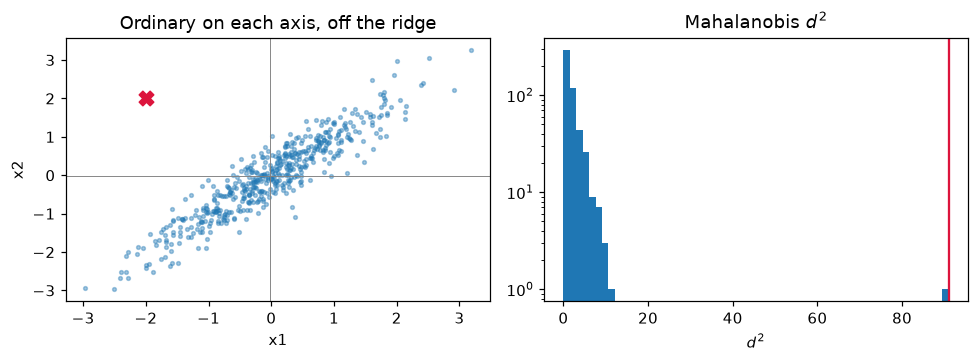

Neither coordinate is remarkable. The combination is impossible.
This is what a per-column outlier check can never see, and it is why the covariance
belongs in the distance.


In [6]:
# ---------------------------------------------------------------------------
# A point inside every marginal range, off the correlation axis.
# ---------------------------------------------------------------------------
r = np.random.default_rng(RANDOM_STATE)
L = np.linalg.cholesky(np.array([[1.0, 0.92], [0.92, 1.0]]))
Xm = np.vstack([r.normal(0, 1, (500, 2)) @ L.T, [[-2.0, 2.0]]])

zm = np.abs((Xm - Xm.mean(0)) / Xm.std(0, ddof=1))
mu_m, Sm = Xm.mean(0), np.cov(Xm.T)
d2 = np.einsum("ij,jk,ik->i", Xm - mu_m, np.linalg.inv(Sm), Xm - mu_m)

print(f"the suspicious point is {Xm[-1]}\n")
print(f"  its per-feature |z|              : {zm[-1][0]:.2f} and {zm[-1][1]:.2f}")
print(f"  the largest |z| anywhere in data : {zm.max():.2f}")
print(f"  its rank by max |z|              : {int((zm.max(1) >= zm[-1].max()).sum())} "
      f"of {len(Xm)}")
print(f"  its rank by Mahalanobis d^2      : {int((d2 >= d2[-1]).sum())} of {len(Xm)}")
print(f"  its d^2 = {d2[-1]:.1f}; the next largest is {np.sort(d2)[-2]:.1f}")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].scatter(Xm[:-1, 0], Xm[:-1, 1], s=6, alpha=0.4)
ax[0].scatter(*Xm[-1], s=90, marker="X", color="crimson", zorder=5)
ax[0].axvline(Xm[:, 0].mean(), lw=0.6, color="grey")
ax[0].axhline(Xm[:, 1].mean(), lw=0.6, color="grey")
ax[0].set(title="Ordinary on each axis, off the ridge", xlabel="x1", ylabel="x2")
ax[1].hist(d2, bins=60)
ax[1].axvline(d2[-1], color="crimson", lw=1.5)
ax[1].set(title="Mahalanobis $d^2$", xlabel="$d^2$", yscale="log")
fig.tight_layout(); plt.show()

print("Neither coordinate is remarkable. The combination is impossible.")
print("This is what a per-column outlier check can never see, and it is why the covariance")
print("belongs in the distance.")

## 1.5 Distance and density: kNN distance and LOF

Drop the assumption that normal data is one Gaussian blob and you get the two workhorse
non-parametric detectors.

**kNN distance** — score a point by the mean distance to its $k$ nearest neighbours. Far from
everything means anomalous. Simple, effective, and **global**: it compares every point against
one implicit scale.

**Local Outlier Factor** (Breunig et al., 2000) fixes that. Real data has regions of different
density, and a point that is loose by the standards of a *tight* cluster may still be closer to
its neighbours than a typical member of a *sparse* one. LOF compares each point's density with
**its own neighbours'** density:

1. $k\text{-dist}(p)$ — the distance to the $k$-th nearest neighbour.
2. $\text{reach-dist}_k(p, o) = \max(k\text{-dist}(o),\, d(p, o))$ — a smoothing device: you
   cannot be closer to $o$ than $o$'s own neighbourhood radius.
3. $\text{lrd}(p) = 1 / \overline{\text{reach-dist}_k(p, o)}$ — local reachability density.
4. $$ \text{LOF}(p) = \frac{\overline{\text{lrd}(o)}}{\text{lrd}(p)} $$

**LOF ≈ 1** means "as dense as my neighbours"; **> 1** means "in a sparser spot than they are".
The ratio is the whole idea, and it is one line of code.

my LOF vs sklearn's: max |difference| = 1.75e-09

score                         rank of the local outlier
--------------------------------------------------------
LOF (k=20)                                     1 of 601
mean kNN distance (k=20)                      31 of 601
Isolation Forest                              11 of 601
distance to global mean                      570 of 601

its LOF is 4.82; the median LOF elsewhere is 1.03


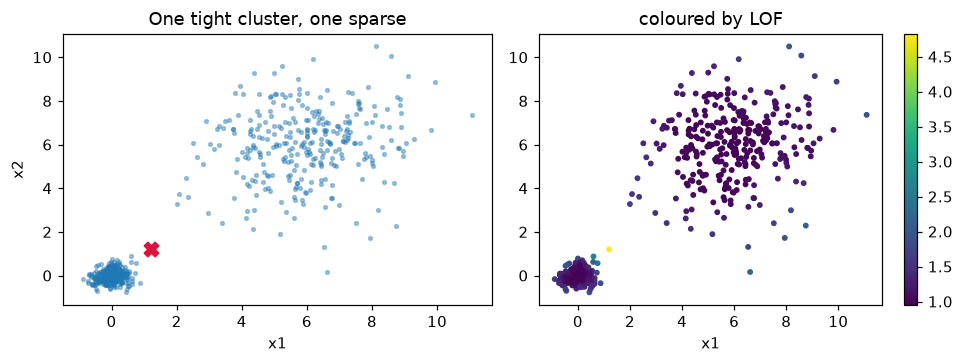

The global scores rank it as unremarkable - it is nearer the middle of everything
than most of the sparse cluster is. Only the LOCAL comparison sees it.

Cost: LOF needs the k-nearest-neighbour graph, so it is O(n^2) without an index and
O(n log n) with one (NB-07 3.2). It also has no 'predict' for new data unless you
build it with novelty=True, because the score is defined relative to the training set.


In [7]:
# ---------------------------------------------------------------------------
# LOF from scratch, checked against sklearn on the same data.
# ---------------------------------------------------------------------------
def lof_scores(X, k=20):
    """Breunig et al. (2000), written out. Returns one LOF value per row."""
    dist, idx = NearestNeighbors(n_neighbors=k + 1).fit(X).kneighbors(X)
    dist, idx = dist[:, 1:], idx[:, 1:]                  # drop each point's own zero
    k_dist = dist[:, -1]                                 # distance to the k-th neighbour
    reach = np.maximum(k_dist[idx], dist)                # reachability distance
    lrd = 1.0 / (reach.mean(axis=1) + 1e-12)             # local reachability density
    return lrd[idx].mean(axis=1) / lrd                   # neighbours' density / mine


# Two clusters of very different density, plus one point loose beside the tight one.
r = np.random.default_rng(RANDOM_STATE)
X_LD = np.vstack([r.normal([0, 0], 0.30, (300, 2)),      # tight
                  r.normal([6, 6], 1.60, (300, 2)),      # sparse
                  [[1.2, 1.2]]])                         # the local outlier

mine = lof_scores(X_LD, k=20)
skl = -LocalOutlierFactor(n_neighbors=20).fit(X_LD).negative_outlier_factor_
print(f"my LOF vs sklearn's: max |difference| = {np.abs(mine - skl).max():.2e}\n")

knn_d = NearestNeighbors(n_neighbors=21).fit(X_LD).kneighbors(X_LD)[0][:, 1:].mean(1)
glob = np.linalg.norm(X_LD - X_LD.mean(0), axis=1)
iso = -IsolationForest(n_estimators=300, random_state=RANDOM_STATE) \
    .fit(X_LD).score_samples(X_LD)

print(f"{'score':<28} {'rank of the local outlier':>26}")
print("-" * 56)
for name, s in [("LOF (k=20)", mine), ("mean kNN distance (k=20)", knn_d),
                ("Isolation Forest", iso), ("distance to global mean", glob)]:
    print(f"{name:<28} {str(int((s >= s[-1]).sum())) + ' of ' + str(len(X_LD)):>26}")

print(f"\nits LOF is {mine[-1]:.2f}; the median LOF elsewhere is {np.median(mine[:-1]):.2f}")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].scatter(X_LD[:-1, 0], X_LD[:-1, 1], s=6, alpha=0.4)
ax[0].scatter(*X_LD[-1], s=90, marker="X", color="crimson", zorder=5)
ax[0].set(title="One tight cluster, one sparse", xlabel="x1", ylabel="x2")
sc = ax[1].scatter(X_LD[:, 0], X_LD[:, 1], c=mine, s=8, cmap="viridis")
ax[1].set(title="coloured by LOF", xlabel="x1")
fig.colorbar(sc, ax=ax[1]); fig.tight_layout(); plt.show()

print("The global scores rank it as unremarkable - it is nearer the middle of everything")
print("than most of the sparse cluster is. Only the LOCAL comparison sees it.")
print()
print("Cost: LOF needs the k-nearest-neighbour graph, so it is O(n^2) without an index and")
print("O(n log n) with one (NB-07 3.2). It also has no 'predict' for new data unless you")
print("build it with novelty=True, because the score is defined relative to the training set.")

## 1.6 Isolation Forest from scratch

Every method so far models *normality* and measures distance from it. Liu, Ting & Zhou (2008)
inverted the problem: **anomalies are easier to separate**, so measure how much work separation
takes.

Build a tree by repeatedly picking a random feature and a random split value between that
feature's current min and max. A point in a sparse region gets cut off after a few splits; a
point in the middle of the crowd needs many. **The path length is the score.**

Averaged over many trees on random subsamples, normalise by the expected path length of an
unsuccessful search in a binary search tree,

$$ c(n) = 2H(n-1) - \frac{2(n-1)}{n}, \qquad s(x) = 2^{-\,\overline{h(x)} / c(n)} $$

so that $s \to 1$ means "isolated fast, anomalous" and $s \approx 0.5$ means "average".

**Why it is the default choice**: it is $O(n \log n)$, needs no distance metric, is unaffected
by feature scaling (§1.9), works in high dimensions where density estimates fail (§3.1), and has
essentially one parameter — `max_samples`, which the paper fixes at **256** and which really
does not need tuning.

In [8]:
# ---------------------------------------------------------------------------
# Isolation Forest from scratch, checked against sklearn.
# ---------------------------------------------------------------------------
def c_factor(n):
    """Expected path length of an unsuccessful search in a BST of n points."""
    if n <= 1:
        return 1e-9
    return 2.0 * (np.log(n - 1) + 0.5772156649) - 2.0 * (n - 1) / n


def build_itree(X, idx, depth, limit, rng):
    if depth >= limit or len(idx) <= 1:
        return {"leaf": True, "size": len(idx), "depth": depth}
    f = int(rng.integers(X.shape[1]))                     # a random feature
    lo, hi = X[idx, f].min(), X[idx, f].max()
    if lo == hi:
        return {"leaf": True, "size": len(idx), "depth": depth}
    p = rng.uniform(lo, hi)                               # a random split point
    return {"leaf": False, "f": f, "p": p,
            "L": build_itree(X, idx[X[idx, f] < p], depth + 1, limit, rng),
            "R": build_itree(X, idx[X[idx, f] >= p], depth + 1, limit, rng)}


def path_length(node, x):
    if node["leaf"]:
        return node["depth"] + c_factor(node["size"])     # credit for the unbuilt subtree
    return path_length(node["L"] if x[node["f"]] < node["p"] else node["R"], x)


def iforest_scores(X, n_trees=100, max_samples=256, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    m = min(max_samples, len(X))
    limit = int(np.ceil(np.log2(m)))                      # the paper's height limit
    trees = [build_itree(X, rng.choice(len(X), m, replace=False), 0, limit, rng)
             for _ in range(n_trees)]
    h = np.array([[path_length(t, x) for t in trees] for x in X]).mean(1)
    return 2.0 ** (-h / c_factor(m))


r = np.random.default_rng(RANDOM_STATE)
X_IF = np.vstack([r.normal(0, 1, (480, 2)), r.uniform(-6, 6, (20, 2))])
Y_IF = np.zeros(len(X_IF), dtype=int); Y_IF[480:] = 1

t0 = time.time(); mine = iforest_scores(X_IF); t_mine = time.time() - t0
t0 = time.time()
skl = -IsolationForest(n_estimators=100, max_samples=256,
                       random_state=RANDOM_STATE).fit(X_IF).score_samples(X_IF)
t_skl = time.time() - t0

print(f"correlation with sklearn : {np.corrcoef(mine, skl)[0, 1]:.4f}")
print(f"top-20 overlap           : "
      f"{len(set(np.argsort(-mine)[:20]) & set(np.argsort(-skl)[:20]))}/20")
print(f"my score range           : {mine.min():.3f} .. {mine.max():.3f}  "
      f"(0.5 = average depth, 1.0 = isolated immediately)")
print(f"speed                    : mine {t_mine:.2f}s, sklearn {t_skl:.2f}s")
print(f"ROC-AUC, mine {roc_auc_score(Y_IF, mine):.4f} | sklearn {roc_auc_score(Y_IF, skl):.4f}")
print()
print("The implementations agree. Note what the scratch version does NOT contain: no")
print("distance, no covariance, no density estimate, no scaling step. It splits at random")
print("and counts. That is the whole algorithm.")

correlation with sklearn : 0.9875
top-20 overlap           : 19/20
my score range           : 0.364 .. 0.805  (0.5 = average depth, 1.0 = isolated immediately)
speed                    : mine 0.52s, sklearn 0.22s
ROC-AUC, mine 0.9344 | sklearn 0.9401

The implementations agree. Note what the scratch version does NOT contain: no
distance, no covariance, no density estimate, no scaling step. It splits at random
and counts. That is the whole algorithm.


## 1.7 One-Class SVM and reconstruction error

Two more families worth knowing, both **semi-supervised** by nature — they are at their best
fitted on data you believe is clean.

**One-Class SVM** (Schölkopf et al., 2001) fits a boundary that encloses most of the training
data, in the kernel feature space, with the margin pushed as far from the origin as possible.
The parameter `nu` upper-bounds the fraction of training points allowed outside — so it is both
a regularisation term and, awkwardly, a contamination guess. It is $O(n^2)$ to $O(n^3)$, so on
anything large you fit it on a subsample.

**Reconstruction error** is the idea behind every autoencoder-based detector, and you can
demonstrate it with PCA (NB-09). Compress to $k$ components and project back; the residual
$\|x - \hat{x}\|^2$ is the score. The claim is that a low-rank model learns the structure of
normal data, so anomalies — which do not share that structure — reconstruct badly.

An autoencoder is the same argument with a non-linear encoder. It is worth stating plainly that
**for tabular data the non-linearity usually buys very little**, and PCA gives you the same
detector with no training loop, no architecture and no epochs.

In [9]:
# ---------------------------------------------------------------------------
# Reconstruction error as an anomaly score, and how it depends on the rank.
# ---------------------------------------------------------------------------
def recon_error(X, n_components, seed=RANDOM_STATE):
    p = PCA(n_components=n_components, random_state=seed).fit(X)
    return ((X - p.inverse_transform(p.transform(X))) ** 2).sum(axis=1), p


print("PCA reconstruction error on the fraud data, by how many components you keep:\n")
print(f"  {'components':>11} {'variance kept':>14} {'ROC-AUC':>9} {'PR-AUC':>9}")
print("  " + "-" * 48)
for k in [1, 2, 3, 5, 10, 20, 25, 28]:
    s, p = recon_error(X_CCS, k)
    print(f"  {k:>11} {p.explained_variance_ratio_.sum():>14.3f} "
          f"{roc_auc_score(Y_CC, s):>9.4f} {average_precision_score(Y_CC, s):>9.4f}")
print(f"  {'(base rate)':>11} {'':>14} {0.5:>9.4f} {Y_CC.mean():>9.4f}")

print()
print("The peak is at TWO components out of 29 - a model that discards 80% of the")
print("variance. Keep almost all of it and the detector collapses, because a 28-component")
print("model of a 29-dimensional space reconstructs the frauds as faithfully as it")
print("reconstructs everything else, and the residual stops carrying information.")
print()
print("The opposite failure is real and does not bite here: with too few components normal")
print("rows reconstruct badly too, and k=1 is already slightly worse than k=2. Either way")
print("THE RANK IS THE MODEL, and it is the parameter to sweep.")
print()
print("An autoencoder replaces the linear projection with a trained encoder-decoder. Same")
print("score, same failure modes, plus an architecture and a training loop to get wrong.")

PCA reconstruction error on the fraud data, by how many components you keep:

   components  variance kept   ROC-AUC    PR-AUC
  ------------------------------------------------
            1          0.135    0.8951    0.1140
            2          0.195    0.8967    0.1275
            3          0.238    0.8869    0.1210
            5          0.317    0.8755    0.1165
           10          0.491    0.8589    0.1082
           20          0.808    0.8312    0.0940
           25          0.937    0.8183    0.0965
           28          0.998    0.7030    0.0457
  (base rate)                   0.5000    0.0122

The peak is at TWO components out of 29 - a model that discards 80% of the
variance. Keep almost all of it and the detector collapses, because a 28-component
model of a 29-dimensional space reconstructs the frauds as faithfully as it
reconstructs everything else, and the residual stops carrying information.

The opposite failure is real and does not bite here: with too few comp

## 1.8 `contamination` is a threshold, not a model

Every sklearn detector takes a `contamination` argument, and it is the single most misunderstood
parameter in this part of the library. It is asking **what fraction of your data are anomalies**
— which is usually the thing you are trying to find out.

The important fact is what it does *not* do. For `IsolationForest`, contamination is used
**only** to pick the cut-off on the already-computed scores. The trees, the path lengths, the
ranking — none of them depend on it.

So the honest way to use these tools is: **get the scores, look at their distribution, and
choose the threshold from your alert budget.** If your team can review 100 cases a day, your
threshold is the 100th highest score, and no statistical argument is involved.

In [10]:
# ---------------------------------------------------------------------------
# Same data, five contamination settings. Watch the scores, not the labels.
# ---------------------------------------------------------------------------
scores = {}
print(f"  {'contamination':>14} {'flagged':>8} {'precision':>10} {'recall':>8} {'ROC-AUC':>9}")
print("  " + "-" * 54)
for cont in [0.01, 0.02, 0.04, 0.08, 0.20]:
    m = IsolationForest(n_estimators=200, contamination=cont,
                        random_state=RANDOM_STATE).fit(X_IF)
    pred = (m.predict(X_IF) == -1).astype(int)
    scores[cont] = -m.score_samples(X_IF)
    tp = int((pred & Y_IF).sum())
    print(f"  {cont:>14.2f} {pred.sum():>8} {tp/max(pred.sum(),1):>10.4f} "
          f"{tp/Y_IF.sum():>8.4f} {roc_auc_score(Y_IF, scores[cont]):>9.4f}")

base = scores[0.01]
print(f"\n  largest |score difference| across all five settings: "
      f"{max(np.abs(v - base).max() for v in scores.values()):.2e}")
print("  The scores are bit-for-bit identical. ROC-AUC is identical. Only the cut moved.")
print()
print("  Precision falls from 1.00 to 0.18 and recall rises - the ordinary precision/recall")
print("  trade-off from NB-11 3.3, reached by turning a knob that never touched the model.")
print()
print("  So: fit once, keep the SCORES, and set the threshold from the alert budget.")

   contamination  flagged  precision   recall   ROC-AUC
  ------------------------------------------------------
            0.01        5     1.0000   0.2500    0.9408
            0.02       10     1.0000   0.5000    0.9408
            0.04       20     0.7000   0.7000    0.9408
            0.08       40     0.3750   0.7500    0.9408
            0.20      100     0.1800   0.9000    0.9408

  largest |score difference| across all five settings: 0.00e+00
  The scores are bit-for-bit identical. ROC-AUC is identical. Only the cut moved.

  Precision falls from 1.00 to 0.18 and recall rises - the ordinary precision/recall
  trade-off from NB-11 3.3, reached by turning a knob that never touched the model.

  So: fit once, keep the SCORES, and set the threshold from the alert budget.


## 1.9 Scale: which detectors care

A rule you can carry: **anything built on distances is destroyed by unequal scaling, and
Isolation Forest does not care.**

The reason is structural. LOF, kNN distance, One-Class SVM's RBF kernel and Mahalanobis all
combine features through a distance, so a feature measured in thousands drowns one measured in
units. Isolation Forest splits **one feature at a time** at a random point between that
feature's own min and max — a monotone rescaling of any column changes nothing about which
points end up on which side.

This matters immediately for the fraud data: `Amount` has a standard deviation of about **250**
while the PCA components have standard deviations near 1.

In [11]:
# ---------------------------------------------------------------------------
# Multiply one feature by a constant and watch three detectors react.
# ---------------------------------------------------------------------------
r = np.random.default_rng(RANDOM_STATE)
X_SC = np.vstack([r.normal(0, 1, (800, 2)),
                  [[4.5, 0.0], [-4.5, 0.0], [0.0, 4.5], [0.0, -4.5]]])
Y_SC = np.zeros(len(X_SC), dtype=int); Y_SC[-4:] = 1

print(f"  {'feature 2 multiplied by':>24} {'IForest':>9} {'LOF':>9} {'OC-SVM':>9} "
      f"{'Mahalanobis':>12}")
print("  " + "-" * 68)
for mult in [1, 10, 100, 1000]:
    Z = X_SC.copy(); Z[:, 1] *= mult
    si = -IsolationForest(n_estimators=300, random_state=RANDOM_STATE).fit(Z).score_samples(Z)
    sl = -LocalOutlierFactor(n_neighbors=20).fit(Z).negative_outlier_factor_
    so = -OneClassSVM(kernel="rbf", gamma="scale", nu=0.05).fit(Z).score_samples(Z)
    sm = np.einsum("ij,jk,ik->i", Z - Z.mean(0), np.linalg.inv(np.cov(Z.T)), Z - Z.mean(0))
    print(f"  {mult:>24,} {roc_auc_score(Y_SC, si):>9.4f} {roc_auc_score(Y_SC, sl):>9.4f} "
          f"{roc_auc_score(Y_SC, so):>9.4f} {roc_auc_score(Y_SC, sm):>12.4f}")

print()
print("Isolation Forest is unchanged to four decimal places - it never compares features.")
print("LOF loses most of its signal, from a perfect 1.0000 to the low 0.6s - on a problem")
print("this easy that is close to useless. The OC-SVM degrades more slowly because")
print("gamma='scale' partly compensates for the inflated variance. Mahalanobis is")
print("unaffected for the opposite reason to the forest: it divides by the covariance, so")
print("it rescales the features itself.")
print()
print("Practical rule: StandardScaler before any distance-based detector, always, and it is")
print("harmless before Isolation Forest - so just always scale.")

   feature 2 multiplied by   IForest       LOF    OC-SVM  Mahalanobis
  --------------------------------------------------------------------
                         1    0.9978    1.0000    1.0000       1.0000
                        10    0.9978    0.9997    0.9981       1.0000
                       100    0.9978    0.9856    0.9900       1.0000
                     1,000    0.9978    0.6216    0.8594       1.0000

Isolation Forest is unchanged to four decimal places - it never compares features.
LOF loses most of its signal, from a perfect 1.0000 to the low 0.6s - on a problem
this easy that is close to useless. The OC-SVM degrades more slowly because
gamma='scale' partly compensates for the inflated variance. Mahalanobis is
unaffected for the opposite reason to the forest: it divides by the covariance, so
it rescales the features itself.

Practical rule: StandardScaler before any distance-based detector, always, and it is
harmless before Isolation Forest - so just always scale.


***
# Part 2 - Worked example: finding card fraud with no labels

Part 1 built the detectors. This part runs all of them on the same real data, on the same
footing, and reports the numbers a fraud team would actually be shown.

The data was loaded in §1.2: 284,807 real card transactions with 492 frauds (0.173%). `V1..V28`
are principal components published in place of the original features — the bank could not
release the raw ones — plus the transaction `Amount`. We work on a stratified subsample of
40,492 rows so the $O(n^2)$ methods finish.

**The labels exist here, and that is the only reason this notebook can tell you anything.** Use
them exactly as a researcher does: to score detectors that never saw them, so that we can find
out what the scores would have been worth.

## 2.1 Six detectors, one table

Every detector below produces a score per row where higher means more anomalous. None of them
sees a label. The baseline is a uniform random score, and it is not decoration — with a 1.2%
base rate, a metric with no baseline beside it is unreadable.

In [12]:
# ---------------------------------------------------------------------------
# All six, scored the same way. Nothing here uses Y_CC except the metrics.
# ---------------------------------------------------------------------------
def precision_at_k(y_true, score, k):
    """Of the k highest-scoring rows, what fraction were really anomalies?"""
    return float(y_true[np.argsort(-score)[:k]].mean())


results = []


def evaluate(name, score, seconds):
    results.append({
        "detector": name,
        "ROC-AUC": roc_auc_score(Y_CC, score),
        "PR-AUC": average_precision_score(Y_CC, score),
        "P@100": precision_at_k(Y_CC, score, 100),
        "P@500": precision_at_k(Y_CC, score, 500),
        "secs": seconds,
    })


t0 = time.time()
S_IFOREST = -IsolationForest(n_estimators=200,
                             random_state=RANDOM_STATE).fit(X_CCS).score_samples(X_CCS)
evaluate("Isolation Forest", S_IFOREST, time.time() - t0)

t0 = time.time()
S_LOF20 = -LocalOutlierFactor(n_neighbors=20).fit(X_CCS).negative_outlier_factor_
evaluate("LOF (k=20)", S_LOF20, time.time() - t0)

t0 = time.time()
_mu = X_CCS.mean(0)
S_MAHAL = np.einsum("ij,jk,ik->i", X_CCS - _mu, np.linalg.pinv(np.cov(X_CCS.T)), X_CCS - _mu)
evaluate("Mahalanobis distance", S_MAHAL, time.time() - t0)

t0 = time.time()
S_RECON, _ = recon_error(X_CCS, 10)
evaluate("PCA reconstruction (k=10)", S_RECON, time.time() - t0)

t0 = time.time()
_sub = np.random.default_rng(RANDOM_STATE).choice(len(X_CCS), 8000, replace=False)
S_OCSVM = -OneClassSVM(kernel="rbf", gamma="scale", nu=0.05).fit(X_CCS[_sub]).score_samples(X_CCS)
evaluate("One-Class SVM (8k fit)", S_OCSVM, time.time() - t0)

t0 = time.time()
S_KNN = NearestNeighbors(n_neighbors=21).fit(X_CCS).kneighbors(X_CCS)[0][:, 1:].mean(1)
evaluate("mean kNN distance (k=20)", S_KNN, time.time() - t0)

evaluate("random (baseline)", np.random.default_rng(0).random(len(Y_CC)), 0.0)

res_df = pd.DataFrame(results).sort_values("PR-AUC", ascending=False)
print(res_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nbase rate = {Y_CC.mean():.5f}. A random pick is right {100*Y_CC.mean():.2f}% "
      f"of the time,")
print("so PR-AUC and precision@k must be read against that number, not against 1.0.")

                 detector  ROC-AUC  PR-AUC  P@100  P@500   secs
         Isolation Forest   0.9476  0.5199 0.8800 0.4940 1.2993
   One-Class SVM (8k fit)   0.9350  0.2290 0.1700 0.3020 2.1799
     Mahalanobis distance   0.9317  0.2199 0.2700 0.2580 0.0852
 mean kNN distance (k=20)   0.9403  0.2053 0.2200 0.2660 2.7635
PCA reconstruction (k=10)   0.8589  0.1082 0.1600 0.1520 0.0277
               LOF (k=20)   0.4880  0.0137 0.0200 0.0260 3.0660
        random (baseline)   0.4890  0.0121 0.0200 0.0120 0.0000

base rate = 0.01215. A random pick is right 1.22% of the time,
so PR-AUC and precision@k must be read against that number, not against 1.0.


In [13]:
print("Three things in that table are worth stopping on.\n")
print("1. ISOLATION FOREST WINS, and comfortably. It is also the fastest of the serious")
print("   options, has one parameter nobody tunes, and needed no scaling. That combination")
print("   is why it is the default first thing to try.")
print()
print("2. LOF IS WORSE THAN RANDOM. Not merely weak - its ROC-AUC is BELOW 0.5, which means")
print("   its ranking is slightly inverted: the rows it is most confident about are")
print("   marginally more likely to be normal. On the 2-D data in 1.5 it was the only")
print("   method that worked at all. Section 3.1 is about why, and it has a fix.")
print()
print("   The random baseline did not land exactly on 0.5 either. That is one draw's")
print("   noise and it would move if you reseeded. LOF's 0.4880 is not noise: 3.1")
print("   reproduces it deliberately, explains it, and repairs it.")
print()
print("3. THE GAP BETWEEN ROC-AUC AND PR-AUC IS ENORMOUS. Isolation Forest looks excellent")
print("   on ROC-AUC and mediocre on PR-AUC. That is not a contradiction; it is the")
print("   arithmetic of a 1.2% base rate, exactly as in NB-11 1.5. With 40,000 normal rows,")
print("   a false-positive rate of 5% is 2,000 false alarms - invisible on an ROC curve,")
print("   fatal to a review team. Report PR-AUC and precision@k. ROC-AUC flatters.")

Three things in that table are worth stopping on.

1. ISOLATION FOREST WINS, and comfortably. It is also the fastest of the serious
   options, has one parameter nobody tunes, and needed no scaling. That combination
   is why it is the default first thing to try.

2. LOF IS WORSE THAN RANDOM. Not merely weak - its ROC-AUC is BELOW 0.5, which means
   its ranking is slightly inverted: the rows it is most confident about are
   marginally more likely to be normal. On the 2-D data in 1.5 it was the only
   method that worked at all. Section 3.1 is about why, and it has a fix.

   The random baseline did not land exactly on 0.5 either. That is one draw's
   noise and it would move if you reseeded. LOF's 0.4880 is not noise: 3.1
   reproduces it deliberately, explains it, and repairs it.

3. THE GAP BETWEEN ROC-AUC AND PR-AUC IS ENORMOUS. Isolation Forest looks excellent
   on ROC-AUC and mediocre on PR-AUC. That is not a contradiction; it is the
   arithmetic of a 1.2% base rate, exactly a

## 2.2 The metric a fraud team actually has

Nobody reviews an ROC curve. A fraud team has **capacity**: some number of cases an analyst can
work through in a day. That capacity is the whole evaluation.

**precision@k** — of your top $k$ alerts, how many were real — is the metric that maps onto it,
and it is the one to put in front of a stakeholder, because the sentence "if you review 100
cases a day, 88 of them will be fraud" needs no explanation.

The **lift** over the base rate is the other number worth quoting: how much better than
reviewing 100 random transactions.

In [14]:
# ---------------------------------------------------------------------------
# The alert-budget view: what each detector delivers at a given daily capacity.
# ---------------------------------------------------------------------------
BUDGETS = [50, 100, 250, 500, 1000]
scorers = [("Isolation Forest", S_IFOREST), ("One-Class SVM", S_OCSVM),
           ("Mahalanobis", S_MAHAL), ("PCA reconstruction", S_RECON),
           ("mean kNN distance", S_KNN), ("LOF (k=20)", S_LOF20)]

print("precision@k - of your top k alerts, the fraction that were really fraud\n")
print(f"  {'detector':<26} " + " ".join(f"{'k='+str(b):>8}" for b in BUDGETS))
print("  " + "-" * 72)
for name, s in scorers:
    print(f"  {name:<26} " +
          " ".join(f"{precision_at_k(Y_CC, s, b):>8.3f}" for b in BUDGETS))
print(f"  {'random':<26} " + " ".join(f"{Y_CC.mean():>8.3f}" for _ in BUDGETS))

print("\nrecall@k - of all 492 frauds, the fraction those k alerts would have caught\n")
print(f"  {'detector':<26} " + " ".join(f"{'k='+str(b):>8}" for b in BUDGETS))
print("  " + "-" * 72)
for name, s in scorers:
    print(f"  {name:<26} " +
          " ".join(f"{precision_at_k(Y_CC, s, b)*b/Y_CC.sum():>8.3f}" for b in BUDGETS))

best = max(scorers, key=lambda t: precision_at_k(Y_CC, t[1], 100))
print(f"\nlift at k=100 for {best[0]}: "
      f"{precision_at_k(Y_CC, best[1], 100)/Y_CC.mean():.0f}x the base rate.")
print()
print("Read the two tables together, because they move against each other. Precision falls")
print("as the budget grows - you work further down the ranking, into rows the detector was")
print("less sure about - while recall rises. There is no k that is 'correct'. There is only")
print("the k your team can staff, and the question of whether a missed fraud costs more")
print("than a wasted review.")
print()
print("That trade-off is NB-11 3.4's cost argument, and it belongs to the business, not to")
print("the model.")

precision@k - of your top k alerts, the fraction that were really fraud

  detector                       k=50    k=100    k=250    k=500   k=1000
  ------------------------------------------------------------------------
  Isolation Forest              0.920    0.880    0.692    0.494    0.341
  One-Class SVM                 0.100    0.170    0.252    0.302    0.278
  Mahalanobis                   0.300    0.270    0.400    0.258    0.250
  PCA reconstruction            0.180    0.160    0.116    0.152    0.167
  mean kNN distance             0.320    0.220    0.244    0.266    0.241
  LOF (k=20)                    0.020    0.020    0.036    0.026    0.020
  random                        0.012    0.012    0.012    0.012    0.012

recall@k - of all 492 frauds, the fraction those k alerts would have caught

  detector                       k=50    k=100    k=250    k=500   k=1000
  ------------------------------------------------------------------------
  Isolation Forest              0

## 2.3 The supervised ceiling

The labels exist in this dataset. If they existed in your problem, would you still be doing any
of this?

Almost always: **no**. The honest comparison is a plain logistic regression trained on the same
rows the detector saw, and it is not close.

In [15]:
# ---------------------------------------------------------------------------
# Same split, same features. One model gets labels; the other does not.
# ---------------------------------------------------------------------------
Xtr, Xte, ytr, yte = train_test_split(X_CC, Y_CC, test_size=0.4,
                                      stratify=Y_CC, random_state=RANDOM_STATE)
_sc = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = _sc.transform(Xtr), _sc.transform(Xte)

s_sup = LogisticRegression(max_iter=2000, class_weight="balanced") \
    .fit(Xtr_s, ytr).predict_proba(Xte_s)[:, 1]
s_uns = -IsolationForest(n_estimators=200, random_state=RANDOM_STATE) \
    .fit(Xtr_s).score_samples(Xte_s)

print(f"test set: {len(yte):,} rows, {yte.sum()} fraud\n")
print(f"{'model':<38} {'ROC-AUC':>9} {'PR-AUC':>9} {'P@100':>8}")
print("-" * 68)
for name, s in [("logistic regression (has labels)", s_sup),
                ("Isolation Forest (no labels)", s_uns)]:
    print(f"{name:<38} {roc_auc_score(yte, s):>9.4f} "
          f"{average_precision_score(yte, s):>9.4f} {precision_at_k(yte, s, 100):>8.3f}")
print(f"{'random':<38} {0.5:>9.4f} {yte.mean():>9.4f} {yte.mean():>8.3f}")

print()
print("The supervised model is far ahead on PR-AUC, the metric that matters here. That is")
print("not a surprise and it is not a criticism of the detector - it is the point.")
print()
print("ANOMALY DETECTION IS WHAT YOU DO WHEN YOU CANNOT DO THIS. It is not a better")
print("classifier. If you have labels, build a classifier (NB-11) and use the detector for")
print("the thing it is uniquely good at: 1.2 showed it holding up on a kind of fraud the")
print("supervised model had never seen.")
print()
print("The realistic architecture is both:")
print("  - a SUPERVISED model for the fraud patterns you have already caught, retrained often")
print("  - an UNSUPERVISED detector as the net for whatever is new")
print("  - and every alert either one raises becomes a label, so the supervised half improves")

test set: 16,197 rows, 197 fraud

model                                    ROC-AUC    PR-AUC    P@100
--------------------------------------------------------------------
logistic regression (has labels)          0.9726    0.8503    0.950
Isolation Forest (no labels)              0.9595    0.4970    0.700
random                                    0.5000    0.0122    0.012

The supervised model is far ahead on PR-AUC, the metric that matters here. That is
not a surprise and it is not a criticism of the detector - it is the point.

ANOMALY DETECTION IS WHAT YOU DO WHEN YOU CANNOT DO THIS. It is not a better
classifier. If you have labels, build a classifier (NB-11) and use the detector for
the thing it is uniquely good at: 1.2 showed it holding up on a kind of fraud the
supervised model had never seen.

The realistic architecture is both:
  - a SUPERVISED model for the fraud patterns you have already caught, retrained often
  - an UNSUPERVISED detector as the net for whatever is new
  - 

***
# Part 3 - The uncomfortable parts

Three things that are true of every anomaly-detection project. The first is a whole
investigation; the second and third are the reasons this is harder than it looks.

## 3.1 Why LOF collapsed

§2.1 measured LOF at ROC-AUC 0.488 on the fraud data — below random — after §1.5 showed it as
the only method that found the local outlier in two dimensions. Something specific went wrong,
and finding out what is more useful than the result.

**The usual explanation is the curse of dimensionality**, and it is worth testing rather than
repeating. In high dimensions distances concentrate: every point ends up roughly equidistant
from every other (NB-07 §3.1), so "local density" should stop meaning anything.

In [16]:
# ---------------------------------------------------------------------------
# Hypothesis 1: dimension. Same problem shape, more dimensions.
# ---------------------------------------------------------------------------
r = np.random.default_rng(RANDOM_STATE)
print(f"  {'dims':>6} {'LOF k=20':>10} {'IForest':>9} {'Mahalanobis':>12} "
      f"{'d50/d1':>9}")
print("  " + "-" * 52)
for dim in [2, 4, 8, 16, 32, 64]:
    base = r.normal(0, 1, (2000, dim))
    anom = r.normal(3.0 / np.sqrt(dim), 1, (40, dim))     # a mean shift, held comparable
    Z = np.vstack([base, anom])
    yz = np.zeros(len(Z), dtype=int); yz[-40:] = 1
    sl = -LocalOutlierFactor(n_neighbors=20).fit(Z).negative_outlier_factor_
    si = -IsolationForest(n_estimators=200, random_state=RANDOM_STATE).fit(Z).score_samples(Z)
    sm = np.einsum("ij,jk,ik->i", Z - Z.mean(0), np.linalg.pinv(np.cov(Z.T)), Z - Z.mean(0))
    dd = NearestNeighbors(n_neighbors=51).fit(Z).kneighbors(Z[:500])[0]
    print(f"  {dim:>6} {roc_auc_score(yz, sl):>10.4f} {roc_auc_score(yz, si):>9.4f} "
          f"{roc_auc_score(yz, sm):>12.4f} {float(np.mean(dd[:, 50] / dd[:, 1])):>9.2f}")

print()
print("'d50/d1' is the 50th nearest neighbour's distance divided by the 1st. It falls from")
print("double figures to near 1, so distance concentration is real and severe.")
print()
print("And it does NOT explain the failure. LOF degrades gently and stays well above 0.5 -")
print("at 64 dimensions it is doing BETTER than Isolation Forest. Whatever broke LOF on the")
print("fraud data, 29 dimensions on their own would not have done it.")

    dims   LOF k=20   IForest  Mahalanobis    d50/d1
  ----------------------------------------------------
       2     0.8207    0.9275       0.9274     11.49
       4     0.7995    0.8432       0.8477      3.12
       8     0.8123    0.8267       0.8137      1.82
      16     0.8051    0.8023       0.7938      1.41
      32     0.6942    0.7205       0.6774      1.23
      64     0.7506    0.6655       0.7329      1.14

'd50/d1' is the 50th nearest neighbour's distance divided by the 1st. It falls from
double figures to near 1, so distance concentration is real and severe.

And it does NOT explain the failure. LOF degrades gently and stays well above 0.5 -
at 64 dimensions it is doing BETTER than Isolation Forest. Whatever broke LOF on the
fraud data, 29 dimensions on their own would not have done it.


The second hypothesis comes from reading LOF's definition rather than its reputation. LOF scores
a point by comparing its density to **its own neighbours'** density. So ask what a fraud row's
neighbours actually are.

In [17]:
# ---------------------------------------------------------------------------
# Hypothesis 2: the anomalies are each other's neighbours.
# ---------------------------------------------------------------------------
_, nbr_idx = NearestNeighbors(n_neighbors=21).fit(X_CCS).kneighbors(X_CCS)
fraud_share = Y_CC[nbr_idx[:, 1:]].mean(1)

print(f"  base rate of fraud in the data                      : {Y_CC.mean():.4f}")
print(f"  mean fraud share among a NORMAL row's 20 neighbours : {fraud_share[Y_CC==0].mean():.4f}")
print(f"  mean fraud share among a FRAUD row's 20 neighbours  : {fraud_share[Y_CC==1].mean():.4f}")
print(f"  frauds whose 20 neighbours are majority fraud       : "
      f"{int((fraud_share[Y_CC==1] > 0.5).sum())} of {int(Y_CC.sum())}")

print()
print("There it is. A fraud's neighbourhood is mostly other frauds. Fraud is not scattered")
print("noise - it comes in campaigns: the same stolen card, the same script, the same hour.")
print()
print("Now re-read LOF's definition. It asks 'is this point in a sparser spot than its")
print("neighbours?'. For a point inside a tight cluster of 380 near-identical frauds, the")
print("honest answer is NO - it is in a perfectly ordinary spot for its neighbourhood.")
print("LOF is not malfunctioning. It is answering the question it was asked.")

  base rate of fraud in the data                      : 0.0122
  mean fraud share among a NORMAL row's 20 neighbours : 0.0015
  mean fraud share among a FRAUD row's 20 neighbours  : 0.7642
  frauds whose 20 neighbours are majority fraud       : 382 of 492

There it is. A fraud's neighbourhood is mostly other frauds. Fraud is not scattered
noise - it comes in campaigns: the same stolen card, the same script, the same hour.

Now re-read LOF's definition. It asks 'is this point in a sparser spot than its
neighbours?'. For a point inside a tight cluster of 380 near-identical frauds, the
honest answer is NO - it is in a perfectly ordinary spot for its neighbourhood.
LOF is not malfunctioning. It is answering the question it was asked.


In [18]:
# ---------------------------------------------------------------------------
# Prove the mechanism: same 40 anomalies, arranged differently.
# ---------------------------------------------------------------------------
r = np.random.default_rng(RANDOM_STATE)


def layout(kind):
    base = r.normal(0, 1, (3000, 8))
    if kind == 0:                                   # 40 independent singletons
        a = r.normal(0, 1, (40, 8))
        a = a / np.linalg.norm(a, axis=1, keepdims=True) * 6.0
    else:                                           # 40 split into `kind` clusters
        a = np.vstack([(lambda c: c / np.linalg.norm(c) * 6.0 + r.normal(0, 0.15, (40 // kind, 8)))
                       (r.normal(0, 1, 8)) for _ in range(kind)])
    Z = np.vstack([base, a])
    yz = np.zeros(len(Z), dtype=int); yz[-40:] = 1
    return Z, yz


print("40 anomalies, all the same distance from the centre, arranged four ways.\n")
print(f"  {'arrangement':<30} {'LOF k=20':>10} {'LOF k=200':>11} {'kNN dist':>10} "
      f"{'IForest':>9}")
print("  " + "-" * 74)
for label, kind in [("40 scattered singletons", 0), ("40 in ONE cluster", 1),
                    ("40 in four clusters of 10", 4), ("40 in ten clusters of 4", 10)]:
    Z, yz = layout(kind)
    s20 = -LocalOutlierFactor(n_neighbors=20).fit(Z).negative_outlier_factor_
    s200 = -LocalOutlierFactor(n_neighbors=200).fit(Z).negative_outlier_factor_
    sk = NearestNeighbors(n_neighbors=21).fit(Z).kneighbors(Z)[0][:, 1:].mean(1)
    si = -IsolationForest(n_estimators=300, random_state=RANDOM_STATE).fit(Z).score_samples(Z)
    print(f"  {label:<30} {roc_auc_score(yz, s20):>10.4f} {roc_auc_score(yz, s200):>11.4f} "
          f"{roc_auc_score(yz, sk):>10.4f} {roc_auc_score(yz, si):>9.4f}")

print()
print("The mechanism is exact. LOF fails when the anomaly cluster is LARGER THAN k, because")
print("then a cluster member's k neighbours are all fellow anomalies and its density ratio")
print("comes out at about 1. Split the same 40 points into groups of 10 and k=20 works")
print("again. Raise k to 200 and even the single cluster is found.")
print()
print("Isolation Forest is untouched by any of it: it never asks who your neighbours are.")

40 anomalies, all the same distance from the centre, arranged four ways.

  arrangement                      LOF k=20   LOF k=200   kNN dist   IForest
  --------------------------------------------------------------------------
  40 scattered singletons            1.0000      1.0000     1.0000    0.9945
  40 in ONE cluster                  0.2611      0.9997     0.0000    0.9985
  40 in four clusters of 10          0.9865      1.0000     0.9394    0.9989
  40 in ten clusters of 4            0.9993      1.0000     0.9989    0.9973

The mechanism is exact. LOF fails when the anomaly cluster is LARGER THAN k, because
then a cluster member's k neighbours are all fellow anomalies and its density ratio
comes out at about 1. Split the same 40 points into groups of 10 and k=20 works
again. Raise k to 200 and even the single cluster is found.

Isolation Forest is untouched by any of it: it never asks who your neighbours are.


In [19]:
# ---------------------------------------------------------------------------
# The prediction: if that is the mechanism, raising k must rescue LOF on the
# real fraud data too. Nothing else changes.
# ---------------------------------------------------------------------------
print("LOF on the fraud data, sweeping n_neighbors:\n")
print(f"  {'n_neighbors':>12} {'ROC-AUC':>9} {'PR-AUC':>9} {'P@100':>8}")
print("  " + "-" * 42)
for k in [20, 50, 100, 200, 500, 1000]:
    s = -LocalOutlierFactor(n_neighbors=k).fit(X_CCS).negative_outlier_factor_
    print(f"  {k:>12} {roc_auc_score(Y_CC, s):>9.4f} "
          f"{average_precision_score(Y_CC, s):>9.4f} {precision_at_k(Y_CC, s, 100):>8.3f}")
print(f"  {'Isolation F.':>12} {roc_auc_score(Y_CC, S_IFOREST):>9.4f} "
      f"{average_precision_score(Y_CC, S_IFOREST):>9.4f} "
      f"{precision_at_k(Y_CC, S_IFOREST, 100):>8.3f}")
print(f"  {'base rate':>12} {0.5:>9.4f} {Y_CC.mean():>9.4f} {Y_CC.mean():>8.3f}")

print()
print("The prediction holds. A parameter change takes LOF from worse-than-random to")
print("competitive with the winner, and the value that works is roughly the size of the")
print("anomaly cluster - which is exactly what the mechanism said it would be.")
print()
print("Three things to carry out of this section:")
print("  1. ANOMALIES COME IN GROUPS more often than the textbooks assume - fraud rings,")
print("     failing sensors, a bad deployment. Any method that defines 'anomalous' relative")
print("     to nearby points has a blind spot the size of the group.")
print("  2. THE DEFAULT k IS A MODELLING ASSUMPTION about how big an anomaly cluster can be.")
print("     sklearn's n_neighbors=20 says 'no more than about 20 at once'.")
print("  3. A DETECTOR SCORING BELOW 0.5 IS INFORMATION, not a bug. It means the structure")
print("     is real and your definition of 'unusual' has the sign backwards.")

LOF on the fraud data, sweeping n_neighbors:

   n_neighbors   ROC-AUC    PR-AUC    P@100
  ------------------------------------------
            20    0.4880    0.0137    0.020
            50    0.4987    0.0214    0.120
           100    0.5788    0.0291    0.140
           200    0.7854    0.0698    0.130
           500    0.9545    0.3683    0.260
          1000    0.9575    0.4632    0.610
  Isolation F.    0.9476    0.5199    0.880
     base rate    0.5000    0.0122    0.012

The prediction holds. A parameter change takes LOF from worse-than-random to
competitive with the winner, and the value that works is roughly the size of the
anomaly cluster - which is exactly what the mechanism said it would be.

Three things to carry out of this section:
  1. ANOMALIES COME IN GROUPS more often than the textbooks assume - fraud rings,
     failing sensors, a bad deployment. Any method that defines 'anomalous' relative
     to nearby points has a blind spot the size of the group.
  2. THE 

## 3.2 Evaluating with no labels

Everything above used labels, and in the situation this notebook is about you do not have them.
That is not a detail — it removes cross-validation, model selection, threshold tuning and any
honest claim about accuracy, all at once.

There is no trick that gives them back. There are five things that genuinely help.

In [20]:
# ---------------------------------------------------------------------------
# The choice you cannot make without labels, made visible.
# ---------------------------------------------------------------------------
print("Here is the choice, scored with labels you would not have:\n")
print(f"  {'detector':<28} {'PR-AUC':>9}")
print("  " + "-" * 40)
for name, s in sorted(scorers, key=lambda t: -average_precision_score(Y_CC, t[1])):
    print(f"  {name:<28} {average_precision_score(Y_CC, s):>9.4f}")
print()
print("Best to worst is a factor of about 40. Now cover the right-hand column: on what")
print("grounds would you have picked one? Every detector produced a plausible-looking score")
print("distribution and a plausible-looking top 100.")
print()
print("This is the central practical difficulty of the field, and it is a data-collection")
print("problem wearing a modelling disguise.")

Here is the choice, scored with labels you would not have:

  detector                        PR-AUC
  ----------------------------------------
  Isolation Forest                0.5199
  One-Class SVM                   0.2290
  Mahalanobis                     0.2199
  mean kNN distance               0.2053
  PCA reconstruction              0.1082
  LOF (k=20)                      0.0137

Best to worst is a factor of about 40. Now cover the right-hand column: on what
grounds would you have picked one? Every detector produced a plausible-looking score
distribution and a plausible-looking top 100.

This is the central practical difficulty of the field, and it is a data-collection
problem wearing a modelling disguise.


In [21]:
# ---------------------------------------------------------------------------
# Does the standard advice - 'fit on clean data' - actually hold? Five seeds.
# ---------------------------------------------------------------------------
runs = {}
for seed in range(5):
    r = np.random.default_rng(seed)
    order = r.permutation(len(X_CCS))
    tr, te = order[:len(order)//2], order[len(order)//2:]
    clean = tr[Y_CC[tr] == 0]
    for det, fit_on, rows in [("Isolation Forest", "everything", tr),
                              ("Isolation Forest", "normal only", clean),
                              ("One-Class SVM", "everything", tr),
                              ("One-Class SVM", "normal only", clean)]:
        if det.startswith("Isolation"):
            m = IsolationForest(n_estimators=200, random_state=seed).fit(X_CCS[rows])
        else:
            m = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05).fit(
                X_CCS[r.permutation(rows)[:8000]])
        runs.setdefault((det, fit_on), []).append(
            average_precision_score(Y_CC[te], -m.score_samples(X_CCS[te])))

print("Semi-supervised (fit on rows believed normal) vs unsupervised (fit on all of it).")
print("Held-out half, 5 seeds:\n")
print(f"  {'detector':<20} {'fitted on':<14} {'PR-AUC':>8} {'sd':>7}   per seed")
print("  " + "-" * 72)
for (det, fit_on), v in runs.items():
    v = np.array(v)
    print(f"  {det:<20} {fit_on:<14} {v.mean():>8.4f} {v.std():>7.4f}   "
          + " ".join(f"{x:.3f}" for x in v))

print()
print("The advice is right for ONE of them and backwards for the other, consistently, on")
print("every seed.")
print()
print("  ONE-CLASS SVM more than doubles when the training data is clean. Its boundary is")
print("  fitted to enclose the training points, so anomalies inside that set drag the")
print("  boundary out around themselves - and it then declines to flag their relatives.")
print()
print("  ISOLATION FOREST does BETTER on the contaminated data. It never fits a boundary;")
print("  it splits at random and measures depth, and a 1.2% sprinkling of anomalies barely")
print("  moves a split point. What the contaminated version does have is more rows.")
print()
print("So 'always train on clean data for novelty detection' is not a rule about anomaly")
print("detection. It is a rule about methods that fit a decision boundary.")

Semi-supervised (fit on rows believed normal) vs unsupervised (fit on all of it).
Held-out half, 5 seeds:

  detector             fitted on        PR-AUC      sd   per seed
  ------------------------------------------------------------------------
  Isolation Forest     everything       0.5291  0.0334   0.553 0.561 0.475 0.551 0.505
  Isolation Forest     normal only      0.4064  0.0346   0.444 0.398 0.366 0.450 0.374
  One-Class SVM        everything       0.2300  0.0204   0.258 0.226 0.213 0.248 0.205
  One-Class SVM        normal only      0.5135  0.0365   0.542 0.544 0.473 0.543 0.465

The advice is right for ONE of them and backwards for the other, consistently, on
every seed.

  ONE-CLASS SVM more than doubles when the training data is clean. Its boundary is
  fitted to enclose the training points, so anomalies inside that set drag the
  boundary out around themselves - and it then declines to flag their relatives.

  ISOLATION FOREST does BETTER on the contaminated data. It neve

**What actually helps when you have no labels.**

1. **Get a few labels.** Not a validation set — a hundred. Take your top 100 alerts, have a
   human review them, and you have precision@100 for that detector. It is the cheapest useful
   measurement in the field, and it is the loop every real fraud team runs.
2. **Label by injection.** Plant synthetic anomalies of a kind you care about and measure recall
   on those. It only tells you about the kinds you thought of, which is a real limitation and
   still much better than nothing.
3. **Agreement between unrelated detectors** is weak evidence. If Isolation Forest and
   Mahalanobis both rank a row in the top 50, it is more likely to be genuinely odd — they fail
   in different ways. Do not mistake this for a metric; it measures consensus, not truth.
4. **Look at the alerts.** Anomaly detection is one of the few areas where reading the top 20
   rows is a legitimate and standard validation step. If they are all the same duplicated
   transaction, you have learned something no metric would have told you.
5. **Watch the alert rate over time.** You cannot measure precision, but you can measure whether
   today's rate is ten times yesterday's — which is usually §3.3's problem rather than a
   sudden crime wave.

## 3.3 Drift is not anomaly

Your detector learned what normal looked like *when you fitted it*. Real data moves — prices
rise, a sensor is recalibrated, a new product launches, an upstream team changes a unit. To a
detector, a distribution that has shifted is a very large number of anomalies.

The failure is not that it produces false positives. It is that **the alerts are all the same
event**, and the detector has no way to say so.

In [22]:
# ---------------------------------------------------------------------------
# Fit on one distribution, score streams that have moved.
# ---------------------------------------------------------------------------
r = np.random.default_rng(RANDOM_STATE)
train_ref = r.normal(0, 1, (4000, 4))
det = IsolationForest(n_estimators=300, random_state=RANDOM_STATE).fit(train_ref)
threshold = np.percentile(-det.score_samples(train_ref), 99)   # 1% alert rate by design

print("Fitted on N(0,1) with the threshold set to alert on 1% of training rows.\n")
print(f"  {'incoming stream':<38} {'% flagged':>11} {'alerts/2000':>13}")
print("  " + "-" * 66)
for label, Z in [
    ("unchanged", r.normal(0, 1, (2000, 4))),
    ("mean shifted 0.5 sd", r.normal(0.5, 1, (2000, 4))),
    ("mean shifted 1.0 sd", r.normal(1.0, 1, (2000, 4))),
    ("mean shifted 2.0 sd", r.normal(2.0, 1, (2000, 4))),
    ("spread widened 40%", r.normal(0, 1.4, (2000, 4))),
    ("one genuine anomaly among 2000 normal",
     np.vstack([r.normal(0, 1, (1999, 4)), r.normal(0, 1, (1, 4)) + 6])),
]:
    flagged = np.mean(-det.score_samples(Z) > threshold)
    print(f"  {label:<38} {100*flagged:>10.1f}% {int(flagged*2000):>13,}")

print()
print("A 2-sd shift produces well over a thousand alerts. Not one of them is worth a review:")
print("they are one fact - the population moved - reported two thousand times.")
print()
print("The detector cannot distinguish the two cases, because from inside the model they are")
print("the same measurement. Only you know that a change affecting most rows is a change in")
print("the process and a change affecting a handful is an event.")
print()
print("What to do:")
print("  MONITOR THE ALERT RATE as a first-class metric. A jump in the rate means drift")
print("     until proven otherwise. This is the single most useful monitor you can add.")
print("  COMPARE DISTRIBUTIONS, not rows - a KS test or PSI on each feature between the")
print("     training window and the current one names the feature that moved.")
print("  REFIT ON A ROLLING WINDOW so 'normal' tracks the process (NB-13 3.3). The cost is")
print("     that a slow-moving problem becomes the new normal and stops being reported.")
print("  ALERT ON GROUPS. If 300 rows trip the same way at once, that is one incident.")
print()
print("The tension in the third point has no clean answer. Refit too fast and you normalise")
print("the fault; refit too slowly and you drown in drift. It is a choice about which")
print("failure you would rather have, and it should be made deliberately and written down.")

Fitted on N(0,1) with the threshold set to alert on 1% of training rows.

  incoming stream                          % flagged   alerts/2000
  ------------------------------------------------------------------
  unchanged                                     0.9%            19
  mean shifted 0.5 sd                           3.5%            69
  mean shifted 1.0 sd                          14.1%           283
  mean shifted 2.0 sd                          79.0%         1,579
  spread widened 40%                           13.9%           277
  one genuine anomaly among 2000 normal         1.7%            33

A 2-sd shift produces well over a thousand alerts. Not one of them is worth a review:
they are one fact - the population moved - reported two thousand times.

The detector cannot distinguish the two cases, because from inside the model they are
the same measurement. Only you know that a change affecting most rows is a change in
the process and a change affecting a handful is an event.

***
# Part 4 - Tough questions

***

### Q1. What is anomaly detection, and how is it different from classification?

<details><summary>Answer</summary>

Anomaly detection finds rows that do not fit a model of normal behaviour. Classification learns
a boundary between labelled classes. The difference is not the algorithm — it is what you are
allowed to assume.

| | Classification | Anomaly detection |
|---|---|---|
| Needs labels | yes | **no** |
| Assumes the classes have a distribution | yes, both | only for "normal" |
| Handles a kind never seen before | **no** | **yes** |
| Can be cross-validated | yes | **not without labels** |
| What you tune | the model | mostly the **threshold** |

**The key idea is that "anomaly" is not a class** (§1.1). The anomalies do not share a
distribution — two frauds may have nothing in common except not being normal — and new kinds
keep appearing, so there is nothing stable to learn a boundary around.

§1.2 measures this. Splitting the frauds into two types and hiding one from training, the
supervised model scores **1.0000** on the type it was trained on and **0.7885** on the type it
never saw. Hide the other type instead and it is 0.9752 against **0.9188**. The unsupervised
detector has no "seen" and "unseen" category at all, and does not degrade either way.

**But do not over-read that.** §2.3 measures the other side: with labels available, logistic
regression reaches PR-AUC **0.8503** against Isolation Forest's **0.4970**. Anomaly detection is
what you do when you cannot build a classifier — not a better version of one. The realistic
system is both.

</details>

***

### Q2. Explain the three framings and how you choose between them.

<details><summary>Answer</summary>

Your labels decide, not your preference.

| Framing | Fitted on | Question | Typical methods |
|---|---|---|---|
| **Unsupervised** | everything, anomalies included | "which of these is odd?" | Isolation Forest, LOF, Mahalanobis |
| **Semi-supervised** | **rows believed normal** | "is this new row like the normal ones?" | One-Class SVM, autoencoder, `LocalOutlierFactor(novelty=True)` |
| **Supervised** | labelled both ways | "is this like the anomalies I have seen?" | any classifier — NB-11 |

The standard advice is that if you can get clean training data you should, because a detector
fitted on contaminated data has partly learned to accept the anomalies. **§3.2 measures that and
finds it true for one method and backwards for the other**, consistently across five seeds:

| detector | fitted on everything | fitted on normal only |
|---|---|---|
| One-Class SVM | 0.2300 | **0.5135** |
| Isolation Forest | **0.5291** | 0.4064 |

The mechanism is the distinction worth remembering. **One-Class SVM fits a boundary** that
encloses its training points, so anomalies in the training set drag that boundary out around
themselves. **Isolation Forest fits nothing** — it splits at random and measures depth — so a
1.2% sprinkling of anomalies barely moves a split point, while the contaminated training set has
the advantage of simply containing more rows.

So the rule is not "clean data is better for novelty detection". It is **"clean data is better
for methods that fit a decision boundary"**.

</details>

***

### Q3. Why does the classical z-score outlier rule fail, and what do you use instead?

<details><summary>Answer</summary>

Because the mean and standard deviation it is measured against are **computed from the data that
contains the outliers**. A few extreme points inflate $s$, which shrinks everyone's $z$ —
including theirs. This is **masking**, and it gets worse as the contamination grows.

§1.3 measures it. With 100 clean points from N(50, 5) plus 20 outliers near 80:

| rule | outliers found |
|---|---|
| `|z| > 3` | **0 of 20** |
| modified z (median / MAD) > 3.5 | **20 of 20** |
| IQR: outside 1.5·IQR | **20 of 20** |

The sample sd came out at **11.80** against a robust estimate (1.4826·MAD) of about 5 — more
than twice too large, because the outliers are inside it.

**Use a robust estimator.** Replace the mean with the median and $s$ with the median absolute
deviation:
$$ M_i = \frac{0.6745\,|x_i - \tilde{x}|}{\text{MAD}} $$
or use Tukey's IQR rule. Both have a **breakdown point** of 50% — half your data must be
corrupted before the estimate can be moved arbitrarily — against 0% for the mean, where a single
point can move it as far as you like.

**The same argument applies in $p$ dimensions.** Mahalanobis distance (§1.4) estimates $\Sigma$
from contaminated data and has exactly this problem; `MinCovDet` (Rousseeuw's Minimum Covariance
Determinant) is the robust replacement.

</details>

***

### Q4. How does Isolation Forest work, and why is it usually the first thing to try?

<details><summary>Answer</summary>

It inverts the usual approach. Every other method models normality and measures distance from
it. Liu, Ting & Zhou (2008) observed that **anomalies are easier to separate**, and measured how
much work separation takes.

Build a tree by repeatedly choosing a **random feature** and a **random split value** between
that feature's current min and max. A point in a sparse region is cut off after a couple of
splits; a point in the crowd needs many. Average the path length over many trees, normalise by
$c(n) = 2H(n-1) - 2(n-1)/n$ — the expected path length in a random binary search tree — and
score
$$ s(x) = 2^{-\overline{h(x)}/c(n)} $$
so $s \to 1$ is "isolated immediately" and $s \approx 0.5$ is "average depth". §1.6 implements
this in about twenty lines and matches sklearn.

**Why it is the default:**

- **$O(n \log n)$**, and each tree uses only `max_samples=256` rows regardless of dataset size.
- **No distance metric**, so no scaling step — §1.9 measures its ROC-AUC unchanged to four
  decimals while one feature is multiplied by 1,000 and LOF falls from 1.0000 to the low 0.6s.
- **Works in high dimensions**, where density estimates degrade (§3.1).
- **Essentially no tuning.** `max_samples=256` comes from the paper and is rarely worth changing;
  `contamination` is a threshold, not a model parameter (§1.8).
- On the fraud data it won on every metric and was the fastest serious option (§2.1).

**What it is bad at:** axis-parallel splits mean a *diagonal* structure needs more of them, and
it has no notion of local density, so a genuine local outlier beside a tight cluster is not its
strength (§1.5). Neither cost it anything on real data here.

</details>

***

### Q5. What is LOF, and when does it fail?

<details><summary>Answer</summary>

**Local Outlier Factor** (Breunig et al., 2000) scores a point by comparing its density with
**its own neighbours'** density:
$$ \text{LOF}(p) = \frac{\overline{\text{lrd}(o)}}{\text{lrd}(p)},\qquad
\text{lrd}(p) = 1 \big/ \overline{\max(k\text{-dist}(o),\, d(p,o))} $$
LOF ≈ 1 means "as dense as my neighbourhood"; > 1 means "in a sparser spot than they are". The
ratio is the point: it lets one dataset contain a tight cluster and a sparse one and be judged
correctly in both (§1.5, where LOF ranks the planted local outlier **1st of 601** while distance
to the global mean ranks it 570th).

**And it failed completely on the fraud data — ROC-AUC 0.4880, below random.** §3.1 works out
why, and it is *not* the curse of dimensionality: a controlled sweep from 2 to 64 dimensions
shows LOF degrading gently and beating Isolation Forest at 64.

**The real cause is that anomalies come in groups.** A fraud row's 20 nearest neighbours are on
average **76%** other frauds. Inside a cluster of 380 near-identical frauds, each one's density
genuinely *is* ordinary for its neighbourhood, so LOF ≈ 1 — the method is answering the question
it was asked. The proof is 40 planted anomalies arranged four ways:

| arrangement | LOF k=20 | LOF k=200 |
|---|---|---|
| 40 scattered singletons | 1.0000 | 1.0000 |
| **40 in one cluster** | **0.2611** | 0.9997 |
| 40 in four clusters of 10 | 0.9865 | 1.0000 |
| 40 in ten clusters of 4 | 0.9993 | 1.0000 |

**LOF fails exactly when the anomaly cluster is bigger than $k$.** And the fix the mechanism
predicts works on the real data: raising `n_neighbors` from 20 to 1000 takes fraud detection
from 0.4880 to **0.9575**, competitive with the winner.

So sklearn's `n_neighbors=20` is not a neutral default. It is an assumption that no more than
about 20 anomalies occur at once.

</details>

***

### Q6. Your detector flags 5% of transactions and the team can review 100 a day. What now?

<details><summary>Answer</summary>

Stop using the detector's own labels and use its **scores**.

`contamination` — and `predict()`, which depends on it — is a threshold applied after the fact.
§1.8 shows the anomaly scores are **bit-for-bit identical** (max difference `0.00e+00`) across
every contamination from 0.01 to 0.20; only the cut moves, and precision falls from 1.00 to
0.18 while the model never changes.

So:

1. **Fit once, keep `score_samples`.** Discard `predict`.
2. **Sort, take the top 100.** Your threshold is the 100th highest score. There is no
   statistical question here — the capacity is the threshold.
3. **Report precision@100**, because it is the sentence a stakeholder can act on: "of the 100
   you review, this many will be real". §2.2 measures Isolation Forest at **0.880** on the fraud
   data — 72× the 1.2% base rate.
4. **Re-derive the threshold on a schedule**, since the score distribution drifts (§3.3). A
   fixed numeric cut-off silently becomes a different alert rate.

**And measure precision@k rather than an accuracy.** With a 1.2% base rate, "99% accurate" is
worse than flagging nothing. §2.1 shows the same detector looking excellent on ROC-AUC and
mediocre on PR-AUC — with 40,000 normal rows, a 5% false-positive rate is 2,000 wasted reviews,
which barely registers on an ROC curve.

</details>

***

### Q7. How do you evaluate an anomaly detector when you have no labels?

<details><summary>Answer</summary>

You cannot, in the sense you want. There is no cross-validation, no model selection, no honest
accuracy claim. §3.2 makes the difficulty concrete: the six detectors in §2.1 span a factor of
about **40** in PR-AUC, and with the labels covered there is no principled way to pick.

Five things genuinely help:

1. **Get a hundred labels.** Not a validation set — take your top 100 alerts and have a human
   review them. That is precision@100 for that detector, it costs a day, and it is the loop
   every real fraud team runs.
2. **Inject synthetic anomalies** of a kind you care about and measure recall on those. It only
   tells you about the kinds you thought of. That is a real limitation and much better than
   nothing.
3. **Look for agreement between unrelated detectors.** A row in the top 50 of both Isolation
   Forest and Mahalanobis is more likely genuinely odd, because they fail differently. This is
   evidence, not a metric — it measures consensus, not truth.
4. **Read the top 20 rows.** One of the few fields where eyeballing the output is a legitimate
   validation step. If they are all the same duplicated transaction, you have learned something
   no metric would have told you. (The fraud dataset has **9,144 exact duplicate rows**.)
5. **Monitor the alert rate over time.** You cannot measure precision, but you can measure
   whether today's rate is ten times yesterday's — which is usually drift (§3.3).

**What not to do:** do not tune `contamination` until the alert count looks reasonable and then
report that as validation. You have chosen an output volume, not measured a detector.

</details>

***

### Q8. Should you scale your features first?

<details><summary>Answer</summary>

**Yes, always — but understand which methods it matters for**, because the answer explains what
each method is doing.

§1.9 multiplies one of two features by a constant and re-scores:

| feature 2 × | Isolation Forest | LOF | One-Class SVM | Mahalanobis |
|---|---|---|---|---|
| 1 | 0.9978 | 1.0000 | 1.0000 | 1.0000 |
| 1,000 | **0.9978** | **0.6216** | 0.8594 | **1.0000** |

**Anything built on a distance loses most of its signal**: LOF, kNN distance and the RBF kernel
all combine features into one number, so a feature in thousands drowns one in units.
**Isolation Forest is unaffected to four decimal places**, because it splits one feature at a
time between that feature's own min and max — any monotone rescaling of a column leaves every
split equivalent. **Mahalanobis is also unaffected**, for the opposite reason: it divides by the
covariance, so it does the scaling itself.

This is immediate on the fraud data, where `Amount` has a standard deviation near **250** and the
PCA components have standard deviations near 1.

**Which scaler:** `StandardScaler` is the default, but it uses the mean and sd, which §1.3 shows
are corrupted by the very outliers you are looking for. `RobustScaler` (median and IQR) is the
more defensible choice here, and rarely worse.

**Do not scale away the signal.** If the anomaly *is* the magnitude — a transaction 500× the
normal size — then scaling per-column is fine but dropping the column is not, and neither is
rank-transforming it.

</details>

***

### Q9. How do autoencoders detect anomalies, and do you need one?

<details><summary>Answer</summary>

Train an autoencoder to reconstruct its input through a narrow bottleneck. It learns the
structure of whatever it saw most of — the normal data. Anomalies do not share that structure,
so they reconstruct badly, and $\|x - \hat{x}\|^2$ is the anomaly score.

**PCA is the linear version of exactly this** (§1.7), and demonstrating it with PCA makes the
mechanism visible: **the rank is the model.** Sweeping components on the fraud data, the peak is
at **2 of 29** — a model that discards 80% of the variance — and keeping 28 collapses it from
ROC-AUC 0.8967 to 0.7030, because a 28-component model of a 29-dimensional space reconstructs
the frauds as faithfully as everything else and the residual stops carrying information.
**An autoencoder inherits that trade-off exactly**, with the bottleneck width in place of the
component count — and no validation set to choose it with (§3.2).

**Do you need one?** For tabular data, usually not:

- The non-linearity buys little on tabular features, which is the same finding as NB-05's on
  supervised tabular problems.
- You add an architecture, a learning rate, a number of epochs, an early-stopping rule and a
  GPU — five things to get wrong, none of which has a validation set to be tuned against (§3.2).
- PCA reconstruction gives the same detector in two lines with no training loop.
- §2.1 measures PCA reconstruction as mid-table on real fraud, behind Isolation Forest.

**When it is genuinely the right tool:** images, audio, and sequences, where the structure of
"normal" is not linear in any useful basis — a convolutional autoencoder on manufacturing
inspection images is a real and standard application. For a table of 30 numeric columns, start
with Isolation Forest and only reach for the network if you can show it beating that.

</details>

***

### Q10. What is `contamination` and how should you set it?

<details><summary>Answer</summary>

It is sklearn's estimate of **what fraction of your data are anomalies** — which is usually the
thing you are trying to find out, so the question is circular by construction.

**The thing to know is what it does not do.** For `IsolationForest` it is used *only* to place
the cut-off on scores that were already computed. §1.8 verifies the scores are identical to
`0.00e+00` across settings from 0.01 to 0.20; ROC-AUC does not move; only precision and recall
trade against each other, which is the ordinary threshold trade-off from NB-11 §3.3 reached by
turning a knob that never touched the model.

**So how to set it:**

- **Don't, mostly.** Use `score_samples`, sort, and cut at your alert budget (Q6).
- If you must produce labels, set it from **capacity** — 100 reviews a day out of 40,000 rows is
  0.25% — not from a belief about the true rate.
- If you have a genuine prior (a known historical fraud rate, a regulatory expectation), use it
  and write down where it came from.
- `contamination="auto"` uses the offset from the original paper. It is a reasonable default and
  it is still an arbitrary choice, not an estimate.

**One method where it is not merely a threshold:** One-Class SVM's `nu` upper-bounds the fraction
of training points allowed outside the boundary, so it genuinely changes the fitted model. That
is also why §3.2's contamination result is so much worse for the SVM than for the forest.

</details>

***

### Q11. Your alert volume jumped 10× overnight. What do you check first?

<details><summary>Answer</summary>

**Drift, before anything else** — and specifically, drift in your inputs rather than a crime
wave.

§3.3 fits a detector on N(0,1) with a threshold calibrated to a 1% alert rate, then feeds it
streams that have moved. A **2-standard-deviation shift produces well over a thousand alerts per
2,000 rows**. Not one is worth reviewing: they are a single fact — the population moved —
reported a thousand times.

The order to check:

1. **Did an upstream input change?** A unit change, a new data source, a schema migration, a
   default value that used to be null. This is the most common cause by a wide margin and it is
   an engineering bug, not an anomaly.
2. **Compare distributions, not rows.** A KS test or PSI per feature between the training window
   and today names the column that moved in one step.
3. **Are the alerts all alike?** If 300 rows trip in the same way, that is one incident.
   Clustering the alerts before showing them is the fix, and it is worth building.
4. **Only then consider it real.** A genuine tenfold rise in anomalies is possible — an outage,
   an attack — and it will usually look different: concentrated in time, or in one segment.

**What to build so you are not answering this from scratch:** monitor the **alert rate itself**
as a first-class metric, alert on *its* change, keep the score distribution from the training
window for comparison, and cluster alerts before they reach a human.

**The uncomfortable trade-off** is refitting. Refit on a rolling window and "normal" tracks the
process, so drift stops firing — and a slowly worsening fault becomes the new normal and is
never reported. Refit rarely and you drown in drift. There is no correct answer; there is a
choice about which failure you would rather have, and it should be deliberate and written down.

</details>

***

### Q12. Where does anomaly detection cause harm, and what would you do about it?

<details><summary>Answer</summary>

Four places, and the first is structural rather than a matter of implementation.

1. **"Anomalous" means "unlike the majority", so minorities are anomalous by construction.**
   This is not a bug in a particular model — it is the definition. An unusual name, an unusual
   employment pattern, an unusual transaction rhythm because someone is paid weekly in cash.
   A fraud detector built this way will flag people for being atypical, and the base rate means
   most of those flags are wrong.
2. **The cost of a false positive is not paid by you.** A frozen card, a blocked benefits claim,
   an account locked at the wrong moment. §2.2's precision@k table is a table of *people wrongly
   flagged* as much as it is a table of detection rates, and at a 1.2% base rate the wrong flags
   outnumber the right ones for most of it.
3. **No labels means no fairness audit.** Every method in NB-12 and every group-fairness metric
   needs ground truth. Without labels you cannot even measure whether your detector flags one
   group at five times the rate of another — unless you deliberately go and measure exactly that,
   which is cheap and almost never done.
4. **Feedback loops.** Investigate a group more, find more there, and the model — retrained on
   confirmed cases — concentrates further. This is NB-14 §3.3's dynamic in a setting where the
   consequence is an accusation.

**What to do, concretely:**

- **Measure the alert rate by group**, even without labels. Unequal rates are not proof of bias,
  and they are the number you cannot claim you did not know.
- **Never auto-action a flag.** Anomaly scores are a triage queue for a human, not a decision.
- **Make the appeal path cheaper than the alert.** If flagging costs you nothing and being
  flagged costs a person a day, the economics guarantee over-flagging.
- **Log what was flagged and what it turned out to be**, which is also the only route to the
  labels in Q7.
- **State what "normal" was fitted on.** If the training window is one branch, one country or
  one quarter, everyone outside it is anomalous and that is your choice, not their behaviour.

</details>

***

## Coding challenges

### Challenge 1 — build the label-efficient loop

§3.2 argues that a hundred labels are worth more than any amount of unsupervised cleverness.
Measure it.

1. Start with Isolation Forest scores on the fraud data and *no* labels.
2. Simulate an analyst: reveal the true labels of the top 50 scoring rows only.
3. Train a supervised model on those 50 labelled rows plus a sample of unlabelled rows treated
   as normal. Score everything again and take the next 50.
4. Repeat for 10 rounds and plot PR-AUC against the number of labels revealed. How many labels
   before you beat the pure detector? Before you reach §2.3's fully supervised ceiling of 0.8503?
5. Compare against revealing 50 **random** rows per round instead of the top-scoring ones. The
   gap between those two curves is the value of active learning, and it is the argument you will
   need to make to get the labelling budget.

***

### Challenge 2 — detect the group, not the row

§3.1 shows that clustered anomalies defeat every neighbourhood method, and §3.3 shows that drift
produces thousands of alerts that are one event. Both are the same missing capability.

1. Cluster the top 500 alerts (DBSCAN from NB-10 is a good fit — it has a notion of "noise",
   which is what a genuine singleton anomaly is).
2. Report **incidents** rather than rows: cluster size, a representative member, the features
   that separate the cluster from normal data.
3. Score the incidents. A cluster of 300 near-identical rows is one high-priority item, not 300.
4. Test it on the drift streams from §3.3. Does your incident count stay near 1 when the whole
   population moves? That is the property you want.

***

### Challenge 3 — the honest benchmark

The literature's most damaging finding (Part 6) is that unsupervised detectors are hard to
separate from each other once you evaluate them properly. Reproduce it at small scale.

1. Take five datasets — the fraud data plus four from §5.
2. Run six detectors on each with default parameters, and record PR-AUC.
3. Rank the detectors per dataset and average the ranks. Is any method reliably best?
4. Now allow yourself to tune each detector *with labels*, and re-rank. How much of the apparent
   difference between methods was actually the tuning you could not have done (§3.2)?
5. Write the paragraph you would send a colleague who wants to know which detector to use. The
   honest version of that paragraph is short, and Part 6's ADBench reached the same conclusion
   across 30 algorithms and 57 datasets.

***
# Part 5 - Five datasets to practise on

| # | Dataset | Scale | The skill it forces | Difficulty |
|---|---|---|---|---|
| 1 | **Credit-card fraud, full size** | 284,807 × 29 | Scale, and whether §2.1 survives it | ★★☆☆☆ |
| 2 | **Shuttle** | 58,000 × 9 | **Several anomaly classes at once** | ★★☆☆☆ |
| 3 | **Thyroid** | 3,772 × 52 | Mixed types, tiny data, medical costs | ★★★☆☆ |
| 4 | **KDD Cup 99** | 100,000+ | **Categorical features** and a broken benchmark | ★★★★☆ |
| 5 | **Digits as novelty** | 1,797 × 64 | The **semi-supervised** framing, cleanly | ★★★☆☆ |

In [23]:
# Shuttle: the classic multi-class anomaly benchmark. Class 1 is "normal"; the
# rest are rare states, and they are NOT one distribution.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    _sh = fetch_openml(data_id=40685, as_frame=True, parser="auto")

sh_X = _sh.data.to_numpy(dtype=float)
sh_cls = _sh.target.astype(int).to_numpy()
print(f"shuttle: {sh_X.shape}")
print("class counts:", dict(pd.Series(sh_cls).value_counts().sort_index()))

sh_y = (sh_cls != 1).astype(int)
print(f"\ntreating class 1 as normal: {sh_y.sum():,} anomalies ({100*sh_y.mean():.2f}%)")
sh_s = -IsolationForest(n_estimators=200,
                        random_state=RANDOM_STATE).fit(sh_X).score_samples(sh_X)
print(f"Isolation Forest ROC-AUC {roc_auc_score(sh_y, sh_s):.4f}, "
      f"PR-AUC {average_precision_score(sh_y, sh_s):.4f}")

print("\nPR-AUC by anomaly class - do they behave the same?")
print(f"  {'class':>6} {'count':>7} {'PR-AUC alone':>14}")
print("  " + "-" * 32)
for c in sorted(set(sh_cls)):
    if c == 1:
        continue
    m = (sh_cls == 1) | (sh_cls == c)
    print(f"  {c:>6} {int((sh_cls == c).sum()):>7,} "
          f"{average_precision_score((sh_cls[m] == c).astype(int), sh_s[m]):>14.4f}")

print()
print("They do not. Some rare classes are found easily and others are nearly invisible,")
print("with one aggregate number hiding the difference - which is 1.1's point about")
print("'anomaly' not being a class, in a dataset you can download.")

shuttle: (58000, 9)
class counts: {1: np.int64(45586), 2: np.int64(50), 3: np.int64(171), 4: np.int64(8903), 5: np.int64(3267), 6: np.int64(10), 7: np.int64(13)}

treating class 1 as normal: 12,414 anomalies (21.40%)
Isolation Forest ROC-AUC 0.8617, PR-AUC 0.6845

PR-AUC by anomaly class - do they behave the same?
   class   count   PR-AUC alone
  --------------------------------
       2      50         0.2948
       3     171         0.3814
       4   8,903         0.4002
       5   3,267         0.9901
       6      10         0.1653
       7      13         0.1078

They do not. Some rare classes are found easily and others are nearly invisible,
with one aggregate number hiding the difference - which is 1.1's point about
'anomaly' not being a class, in a dataset you can download.


### 1. Credit-card fraud, at full size

```python
from sklearn.datasets import fetch_openml
cc = fetch_openml(data_id=1597, as_frame=True, parser="auto")   # 284,807 x 29
```

Everything above used a 40,492-row stratified subsample so LOF and One-Class SVM would finish.
Run it properly.

1. Reproduce §2.1's table on all 284,807 rows. Isolation Forest and Mahalanobis scale fine; LOF
   needs an approximate-neighbour index (NB-07 §3.2) or a lot of patience. Time each and report
   the wall-clock cost per detector — that table is as decision-relevant as the accuracy one.
2. Does §3.1's LOF result survive? The clusters are now 7× larger, so the mechanism predicts you
   need a proportionally larger `n_neighbors`. Check whether it does.
3. This data is ordered in time and the original has a `Time` column that OpenML's copy drops.
   Split the first 70% from the last 30% and re-run: does a detector fitted on the earlier period
   still work on the later one (§3.3)?
4. Handle the **9,144 duplicate rows**. Do they inflate or deflate the detectors, and which ones?

***

### 2. Shuttle — several kinds of anomaly at once

```python
sh = fetch_openml(data_id=40685, as_frame=True, parser="auto")  # 58,000 x 9
```

Class 1 is the normal state; classes 2–7 are different rare states with counts from 13 to 8,903.
That mix is the whole exercise.

1. Reproduce the cell above and extend it. Which classes are found and which are invisible?
2. Class 4 has 8,903 members — 15% of the data. Is it an anomaly at all? Try it both ways and
   watch every metric change, which is §1.1's definition problem made concrete.
3. Fit semi-supervised on class 1 only and compare against unsupervised on everything (§3.2).
   With 22% contamination this should separate the methods far more sharply than the fraud data's
   1.2% did.
4. Nine features only. Plot the top-100 alerts in the first two principal components against the
   true classes and see what the detector actually latched onto.

***

### 3. Thyroid — small, mixed, and medically costly

```python
from imblearn.datasets import fetch_datasets     # pip install imbalanced-learn
th = fetch_datasets()["thyroid_sick"]            # 3,772 x 52, 6.12% positive
```

Small enough to run everything, including the expensive methods, in seconds.

1. Run all six detectors. With only 3,772 rows, how stable are the rankings across resamples?
   Bootstrap it and put error bars on §2.1's table — a difference smaller than the bar is not a
   difference.
2. The features are a mix of binary flags and continuous measurements. Does `StandardScaler` do
   the right thing to a binary column? Try `RobustScaler` and a quantile transform (Q8).
3. In a medical setting a false negative is far more costly than a false positive. Work out the
   alert budget from that asymmetry rather than from review capacity (Q6, NB-11 §3.4).
4. 6.12% is a high contamination rate. Test §3.2's semi-supervised comparison here — the effect
   should be much larger than at 1.2%.

***

### 4. KDD Cup 99 — categorical features and a famously flawed benchmark

```python
from sklearn.datasets import fetch_kddcup99
kdd = fetch_kddcup99(subset="SA", percent10=True, as_frame=True)
```

Network intrusion detection, and the most-cited dataset in the field. It is also **known to be
too easy** and full of duplicates — which makes it the ideal place to learn to distrust a
benchmark.

1. Three columns are categorical (`protocol_type`, `service`, `flag`). None of the detectors in
   this notebook accepts them. One-hot encode and watch the dimension explode; try target-free
   alternatives (frequency encoding, hashing) and compare.
2. Get a suspiciously high score, then find out why: count the duplicate rows, and check whether
   the attacks are separable on one or two features alone.
3. Read the critiques (Part 6, and NSL-KDD's motivation) and write down what you would need to
   see before believing a number from this dataset. That skill transfers.
4. `percent10=False` gives roughly five million rows. Which detectors still run?

***

### 5. Digits as a novelty problem — the cleanest semi-supervised setup available

```python
from sklearn.datasets import load_digits
d = load_digits()                     # 1,797 x 64, bundled - no download
# train on the 9s only; every other digit is a novelty
```

A construction rather than a real dataset, and the best way to isolate the semi-supervised
framing (§1.2) from every other variable, because you control exactly what "normal" means.

1. Fit `OneClassSVM` and `LocalOutlierFactor(novelty=True)` on one digit class. Score the rest.
   Which digits are hardest to call novel, and does that match which ones look alike?
2. Now contaminate the training set with 1%, 5%, 10% of other digits and re-measure. This is
   §3.2's experiment with the contamination under your control — plot the degradation curve for
   both methods and see the boundary-fitting one fall faster.
3. Compare against PCA reconstruction error (§1.7) fitted on the same single class, sweeping the
   number of components. Where is the peak, and why is it there?
4. 64 dimensions, 1,797 rows. Sweep LOF's `n_neighbors` and connect what you find to §3.1 — the
   "anomaly cluster" here is an entire digit class, so the mechanism predicts what the useful
   range of $k$ will be. Check the prediction.

**Note:** `load_digits` emits a NumPy 2.5 `DeprecationWarning` from inside sklearn 1.9. Wrap it
in `warnings.catch_warnings()` if you run with warnings as errors.

***
# Part 6 - Reading the literature

A field where the foundational algorithm papers are short and clear, and the most valuable recent
work is entirely about how badly the field evaluates itself.

## Start here

**1. [ADBench: Anomaly Detection Benchmark](https://arxiv.org/abs/2206.09426)** —
Han, Hu, Huang, Jiang & Zhao, NeurIPS 2022. **Free.**
> **30 algorithms, 57 datasets, roughly 100,000 experiments.** Its headline results are the ones
> this notebook keeps running into: **no unsupervised method is statistically better than the
> others**, a small number of labels beats all of them, and supervised beats everything. Read it
> before you spend a month choosing a detector. §2.3 and §3.2 are small demonstrations of the
> same conclusions.

**2. Isolation Forest** — Liu, Ting & Zhou, ICDM 2008.
> **Eight pages, one idea, and the method you will use most.** Anomalies are easier to isolate,
> so measure how many random splits it takes. No distance, no density, no distribution. §1.6
> implements it from the paper in about twenty lines. The 2012 journal version
> (*Isolation-Based Anomaly Detection*, ACM TKDD) adds the analysis of why sub-sampling helps
> rather than hurts, which is the counter-intuitive part.

**3. LOF: Identifying Density-Based Local Outliers** — Breunig, Kriegel, Ng & Sander,
SIGMOD 2000.
> The paper that introduced *local* as the operative word, and the one whose definition you have
> to read carefully to understand §3.1's failure. Every step is spelled out, and the failure mode
> — a cluster of anomalies larger than $k$ — follows directly from the definition rather than
> from any implementation detail.

## The paper behind each section

| Section | Source | Free? |
|---|---|---|
| 1.1 — what an anomaly is; the taxonomy | **Chandola, Banerjee & Kumar**, *Anomaly Detection: A Survey*, ACM Computing Surveys 41(3), **2009** — still the best map of the field | 🔍 |
| 1.3 — the modified z-score | **Iglewicz & Hoaglin**, *How to Detect and Handle Outliers*, ASQC **1993**; and **Rousseeuw & Croux**, *Alternatives to the median absolute deviation*, JASA **1993** | 🔍 |
| 1.4 — robust covariance | **Rousseeuw**, *Least median of squares regression*, JASA **1984**; **Rousseeuw & Van Driessen**, *A fast algorithm for the minimum covariance determinant estimator*, Technometrics **1999** | 🔍 |
| 1.5 — **LOF** | **Breunig, Kriegel, Ng & Sander**, SIGMOD **2000** | 🔍 |
| 1.6 — **Isolation Forest** | **Liu, Ting & Zhou**, ICDM **2008**; journal version ACM TKDD 6(1), **2012** | 🔍 |
| 1.7 — One-Class SVM | **Schölkopf, Platt, Shawe-Taylor, Smola & Williamson**, *Estimating the support of a high-dimensional distribution*, Neural Computation 13(7), **2001** | 🔍 |
| 1.7 — deep and shallow, unified | **Ruff, Kauffmann, Vandermeulen, Montavon, Samek, Kloft, Dietterich & Müller**, *A Unifying Review of Deep and Shallow Anomaly Detection*, Proc. IEEE **2021** — [arXiv](https://arxiv.org/abs/2009.11732) | ✅ |
| 3.1 — **high-dimensional density** | **Zimek, Schubert & Kriegel**, *A survey on unsupervised outlier detection in high-dimensional numerical data*, Stat. Anal. Data Min. **2012** | 🔍 |
| 3.1 — distance concentration | **Beyer, Goldstein, Ramakrishnan & Shaft**, *When is "nearest neighbor" meaningful?*, ICDT **1999** | 🔍 |
| 3.2 — **how to evaluate without labels** | **Campos et al.**, *On the evaluation of unsupervised outlier detection*, Data Mining and Knowledge Discovery 30, **2016** | 🔍 |
| 3.2 — what makes a problem hard | **Emmott, Das, Dietterich, Fern & Wong**, *A Meta-Analysis of the Anomaly Detection Problem*, **2015** | 🔍 |
| 3.2 — **ADBench** | **Han, Hu, Huang, Jiang & Zhao**, NeurIPS **2022** — [arXiv](https://arxiv.org/abs/2206.09426) | ✅ |
| 3.3 — drift | **Gama, Žliobaitė, Bifet, Pechenizkiy & Bouchachia**, *A survey on concept drift adaptation*, ACM Computing Surveys **2014** | 🔍 |
| Q12 — harms | **Barocas, Hardt & Narayanan**, *Fairness and Machine Learning*, [fairmlbook.org](https://fairmlbook.org) — free online | ✅ |

**Legend:** ✅ free at the link · 🔍 search the exact title on
[Google Scholar](https://scholar.google.com)

### If you read only one

**ADBench (2022).** It is the paper that tells you what the previous twenty years of method
papers add up to, and the answer is uncomfortable: across 30 algorithms and 57 datasets, **the
choice of unsupervised algorithm is not the thing that determines your result**. What determines
it is whether you have any labels at all — and a handful is enough to beat every unsupervised
method in the benchmark.

Read it against §3.2, where six detectors span a factor of 40 in PR-AUC with no principled way to
choose between them, and §2.3, where a plain logistic regression with labels beats the best of
them outright. Then read **Isolation Forest** for the method you will actually reach for, and
**LOF** for the one whose failure teaches the most.

***
# Appendix

| Symptom | Cause | Fix |
|---|---|---|
| The z-score rule finds nothing | Masking: outliers inflate the sd (§1.3) | Modified z-score (median/MAD) or the IQR rule |
| Detector flags one column's extremes only | Per-feature thresholds ignore correlation (§1.4) | Mahalanobis distance, or `MinCovDet` if contaminated |
| ROC-AUC below 0.5 | The ranking is inverted — real structure, wrong sign (§3.1) | Find the mechanism; do not just flip the score |
| LOF is useless on real data | Anomalies come in clusters larger than `n_neighbors` (§3.1) | Raise `n_neighbors` above the expected cluster size |
| One feature dominates everything | No scaling before a distance-based method (§1.9) | `StandardScaler`, or `RobustScaler` given §1.3 |
| Great ROC-AUC, useless in production | Base rate ~1% — ROC-AUC flatters (§2.1) | Report PR-AUC and precision@k |
| Changing `contamination` does not help | It is a threshold, not a model parameter (§1.8) | Use `score_samples` and cut at the alert budget |
| Alert volume jumped 10× | Distribution drift, not anomalies (§3.3) | KS/PSI per feature; monitor the alert rate itself |
| Thousands of alerts, all alike | One incident reported once per row (§3.3) | Cluster alerts and report incidents |
| One-Class SVM performs badly | Contaminated training data drags the boundary out (§3.2) | Fit on rows believed normal; or use Isolation Forest |
| Cannot pick between detectors | No labels, so no model selection (§3.2) | Label your top 100 alerts; inject synthetic anomalies |
| Suspiciously high score on a benchmark | Duplicate rows or a leaked shortcut feature (§5, KDD) | Count duplicates; check single-feature separability |
| `LocalOutlierFactor` warns about duplicates | Duplicate rows make the k-distance zero | Raise `n_neighbors`, or de-duplicate first |

## Checklist for shipping an anomaly detector

- [ ] Have I **scaled** the features, and chosen a scaler robust to the outliers I am hunting
      (§1.9, Q8)?
- [ ] Am I using **`score_samples`** rather than `predict`, with the threshold set from the
      **alert budget** (§1.8, Q6)?
- [ ] Do I report **precision@k and PR-AUC** with the **base rate** beside them (§2.1, §2.2)?
- [ ] Have I checked whether **labels exist**, even partially — because if they do, a classifier
      wins (§2.3)?
- [ ] Have I had a human **read the top 20 alerts** (§3.2)?
- [ ] Do I know whether my anomalies are **isolated or clustered**, and have I set
      `n_neighbors` accordingly (§3.1)?
- [ ] Is there a **duplicate-row check**, before anything else?
- [ ] Am I monitoring the **alert rate** and the **score distribution** over time (§3.3)?
- [ ] Do I have a **refit policy**, written down, with its drift/staleness trade-off stated
      (§3.3, Q11)?
- [ ] Are alerts **clustered into incidents** before a human sees them (§3.3)?
- [ ] Is every alert **triage for a person**, never an automatic action (Q12)?
- [ ] Am I measuring the **alert rate by group**, even without labels (Q12)?

## Where to go next

| Notebook | Why it follows |
|---|---|
| [`imbalanced_classification_zero_to_hero.ipynb`](imbalanced_classification_zero_to_hero.ipynb) | The same rare-event problem *with* labels — which §2.3 shows is a much better position to be in. |
| [`knn_zero_to_hero.ipynb`](knn_zero_to_hero.ipynb) | §1.5 and §3.1 are kNN; §3.2 there is the approximate search that makes LOF viable at scale. |
| [`pca_zero_to_hero.ipynb`](pca_zero_to_hero.ipynb) | §1.7's reconstruction-error detector, and the conditioning caveat behind §1.4. |
| [`explainable_ai_zero_to_hero.ipynb`](explainable_ai_zero_to_hero.ipynb) | "Why was this flagged?" is the first question every analyst asks, and an anomaly score does not answer it. |
| [`time_series_zero_to_hero.ipynb`](time_series_zero_to_hero.ipynb) | §3.3's drift problem, and where collective anomalies actually live. |

**This is the last notebook in the series.** See
[`README.md`](README.md) for the full roster, the reading order and the suggested paths.